# Definizione del Progetto: Studio sulla percezione dell'Intelligenza Artificiale in ambito professionale

## Obiettivo principale
Il presente progetto mira a condurre una ricerca per rispondere alle seguenti domande chiave relative all'adozione e alla percezione dell'Intelligenza Artificiale (IA) nel mondo del lavoro:
1. La discussione sull'AI è prevalentemente positiva o negativa nelle diverse professioni?
2. Le percezioni dell'AI cambiano tra professioni differenti?
3. Chi vede l'AI come minaccia e chi come opportunità?
4. Utenti che condividono *stance* sull'AI creano **echo-chambers** oppure c'è un fenomeno di **cross-pollination**?
5. Gruppi di professioni differenti condividono discussioni oppure si trovano in bolle separate?

## Metodologia di Analisi
L'analisi sarà strutturata in diverse fasi metodologiche interconnesse:
* Raccolta di dati provenienti dai social media (Reddit - dump Arctic Shift).
* Stance Analysis tramite LLM locale con quantizzazione.
* Realizzazione di un'analisi di rete (*network analysis*) per mappare le connessioni tra gruppi.
* Interpretazione dei risultati ed estrazione degli insights

### Fonti di Raccolta Dati:
1.  **Piattaforma:** I dati saranno raccolti dal social media **Reddit**.
2.  **Contesto:** Verranno analizzati i commenti di post che trattano argomenti relativi all'Intelligenza Artificiale provenienti da subreddit specifici legati a professioni ben definite.



In [4]:
# Setup e import
import os
import sys

module_path = os.path.abspath(os.path.join('../src/data_retrive.py'))

if module_path not in sys.path:
    sys.path.append(module_path)
from pathlib import Path
from src.data_retrive import runSubredditPipeline
import pandas as pd
from IPython.display import display


# Step 1: Raccolta e Pulizia dei Dati
Per lo studio proposto nel progetto è fondamentale eseguire una raccolta dati strutturata da **Reddit**.
Questi dati sono la materia prima analitica per rispondere alle domande di ricerca sul rapporto tra *Lavoro* e *Intelligenza Artificiale*.
La qualità della raccolta e l'implementazione di campi ben definiti (come il sentiment) sono cruciali per garantire risultati validi e riproducibili in tutte le fasi dell'analisi.

La raccolta e la pulizia dei dati avvengono secondo i seguenti passaggi:
1. Vengono processati i dump files dei post dei vari subreddit considerati
2. Per ogni subreddit, si filtrano i post utilizzando delle keywords relative all'argomento dell'intelligenza artificiale.
3. Si crea una lista di id di post da considerare
4. Vengono puliti i dati dei post di modo da rimuovere post non utili alla ricerca (approfondimento più avanti in questo step)
5. Vengono processati i dump files dei commenti dei vari subreddit considerati
6. Per ogni subreddit, si filtrano i commenti che appartengono ai post selezionati precedentemente per il dato subreddit e che sono di primo livello
7. Vengono salvati tutti i commenti processati per ogni subreddit associando ad ognuno di essi il subreddit da cui è stato recuperato
8. I post e i commenti raccolti vengono ulteriormente puliti ed esplorati per garantire che siano completi, coerenti e rappresentativi del fenomeno oggetto di studio

## Subreddit Considerati
Subreddit considerati nella raccolta dei dati:
- r/AskProgramming
- r/webdev
- r/marketing
- r/graphic_design
- r/artistlounge
- r/copywriting

Per ciascuno di questi subreddit vengono processati sia i dump dei post (passaggio 1) sia, in un secondo momento, i dump dei commenti (passaggio 5).

Sono stati individuati i seguenti subreddit in quanto condividono le seguenti caratteristiche:
- Permettono discussioni su AI
- Mantengono le discussioni legate ad argomenti relativi alle professioni specifiche del subreddit
- Popolate principalmente da professionisti degli ambiti relativi agli argomenti del subreddit

Le seguenti professioni sono state selezionate come elemento di studio in quanto profondamente influenzate dalla pubblicazione e vendita di tool alimentati da AI che vengono utilizzati nelle loro mansioni negli ultimi anni (e in maniera particolare nel 2024, anno scelto per la raccolta dei dati).

## Strumento di Raccolta Dati
La raccolta dei dump viene effettuata mediante i file forniti da Arctic Shift, scelti in virtù della loro maggiore efficienza rispetto alle API e della complessità associata all'accesso alle API ufficiali di Reddit, ritenuta non proporzionata agli obiettivi e alla scala del presente progetto.

Ulteriori modalità di accesso ai dati, quali gli endpoint JSON pubblici, non risultano più disponibili a partire da giugno 2026. Il loro utilizzo richiede infatti la registrazione di un'applicazione e l'ottenimento di specifiche autorizzazioni da parte di Reddit, comportando un processo sostanzialmente analogo a quello previsto per l'accesso alle API ufficiali.

Per ogni subreddit, Arctic Shift fornisce due dump distinti in formato `.jsonl`, uno per i post e uno per i commenti, processati separatamente secondo l'ordine descritto sopra: prima i post (passaggi 1-4), poi i commenti (passaggi 5-7).

### Limiti Temporali
Il dibattito pubblico sull'AI ha avuto un'accelerazione significativa dopo il lancio di ChatGPT a fine 2022.
Si presuppone quindi che precedentemente al 2023 vi erano pochi post rilevanti, si prosegue poi nel 2023 in cui iniziano dibatti più intensi ed interessanti, ma ancora molto caotici.
Partendo dal 2024 il dibattito si può definire più "maturo" con posizioni più solide tra le professioni.

L'anno 2024 risulta quindi quello più interessante per il fenomeno ricercato.

La raccolta dei dati viene dunque limitata ad un intervallo temporale definito: tra il **1 gennaio 2024** e il **31 dicembre 2024**. Questo limite viene applicato uniformemente a tutti i subreddit analizzati, riducendo il rischio di bias legati ad eventi contingenti che potrebbero aver influenzato il dibattito sull'AI in periodi specifici.



In [2]:
# Setup per Raccolta Dati

# Funzioni Ausiliarie

def _find_data_file(folderPath: Path, suffix: str) -> Path | None:
    """Trova il file .jsonl il cui nome termina con il suffisso indicato (es. '_posts', '_comments')."""
    matches = sorted(Path(folderPath).glob(f"*{suffix}.jsonl"))
    return matches[0] if matches else None

def _processed_csv_path(jsonlFile: Path) -> str:
    """Percorso del csv processato: stessa cartella e stesso nome del .jsonl, con suffisso '_processed'."""
    return str(jsonlFile.with_name(jsonlFile.stem + "_processed.csv"))

def _save_dataframe(df: pd.DataFrame, path: str, fields: list[str]):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    df.to_csv(path, columns=fields, index=False, encoding="utf-8")



In [3]:
import json


# STEP 1 - Processamento del dump dei post di un subreddit

def processPostDumps(subredditFolder: str) -> pd.DataFrame:
    """
    Step 1: legge il dump .jsonl dei post di UN singolo subreddit
    (subredditFolder) e lo raccoglie in un DataFrame, senza applicare alcun filtro.
    """
    subredditFolder = Path(subredditFolder)
    postsFile = _find_data_file(subredditFolder, "_posts")
    if postsFile is None:
        raise FileNotFoundError(f"Nessun file di post trovato in {subredditFolder}")

    print(f"- Processing posts file: {postsFile.name}")
    rows = []
    for post in readJSONL(postsFile):
        rows.append({
            "id": post.get("id", ""),
            "author": post.get("author", ""),
            "subreddit": post.get("subreddit", subredditFolder.name),
            "title": post.get("title", "") or "",
            "selftext": post.get("selftext", "") or "",
        })

    df_posts = pd.DataFrame(rows, columns=["id", "author", "subreddit", "title", "selftext"])
    print(f"[STEP 1] Post totali raccolti: {len(df_posts):,}")
    return df_posts

def readJSONL(path: Path):
    """Legge un file .jsonl riga per riga e restituisce i dict corrispondenti."""
    with open(path, "rb") as f:
        for line in f:
            line = line.decode("utf-8", errors="replace").strip()
            if not line:
                continue
            try:
                yield json.loads(line)
            except json.JSONDecodeError:
                print(f"Errore nel parsing della riga in {path.name}")
                continue



## Filtraggio dei Post (Passaggio 2)
Il filtraggio dei post, applicato durante la processazione del dump di ciascun subreddit, si basa sulla presenza di keywords rilevanti all'argomento dell'AI nell'ambito lavorativo.

### Filtraggio per Keywords
La raccolta dei dati viene limitata ai contenuti rilevanti per il tema dell'intelligenza artificiale tramite un filtraggio per keywords.
Vengono inclusi nel dataset esclusivamente i post che contengono almeno una delle keywords definite.

#### Keywords Scelte

| Keyword                 | Significato                                               | Motivazione                                                    |
| ----------------------- | --------------------------------------------------------- | -------------------------------------------------------------- |
| AI                      | Acronimo di Artificial Intelligence                       | Termine più comune e trasversale                               |
| artificial intelligence | Forma estesa di AI                                        | Aumenta la copertura delle discussioni                         |
| machine learning        | Tecniche che permettono ai sistemi di apprendere dai dati | Molto usato in contesti tecnici e professionali                |
| ChatGPT                 | Assistente AI basato su LLM                               | Simbolo principale del dibattito sull'AI                       |
| Copilot                 | Assistente AI per attività professionali                  | Diffuso nell'automazione del lavoro                            |
| Midjourney              | Generatore di immagini tramite AI                         | Rilevante nelle professioni creative                           |
| Stable Diffusion        | Modello open-source per generare immagini                 | Centrale nelle discussioni su arte                             |
| automation              | Automazione di attività lavorative                        | Direttamente collegata all'impatto sul lavoro                  |
| job loss                | Perdita di posti di lavoro                                | Individua discussioni sui rischi occupazionali                 |
| replace                 | Sostituire persone o mansioni                             | Spesso usato nei dibattiti sulla sostituzione del lavoro umano |
| workflow                | Flusso di lavoro professionale                            | Individua discussioni sui cambiamenti operativi                |
| generative AI           | AI capace di generare contenuti                           | Tecnologia al centro delle trasformazioni professionali        |
| LLM                     | Large Language Model                                      | Termine comune nelle discussioni su ChatGPT e simili           |
| prompt                  | Istruzione fornita a un modello AI                        | Rappresenta una competenza pratica nell'uso dell'AI            |


In [59]:
import re

# STEP 2 - Filtraggio dei post per keywords

# Keywords da cercare (case-insensitive, parola intera o sottostringa)
KEYWORDS = [
    "AI",
    "artificial intelligence",
    "machine learning",
    "ChatGPT",
    "Copilot",
    "Midjourney",
    "Stable Diffusion",
    "automation",
    "job loss",
    "replace",
    "workflow",
    "generative AI",
    "LLM",
    "prompt",
]

# Pattern regex compilato una volta sola per performance
_keyword_pattern = re.compile(
    r'(?<!\w)(' + '|'.join(re.escape(kw) for kw in KEYWORDS) + r')(?!\w)',
    re.IGNORECASE
)

def filterPostsByKeywords(df_posts: pd.DataFrame) -> pd.DataFrame:
    """
    Step 2: filtra i post del subreddit tenendo solo quelli che contengono
    almeno una keyword (in titolo o corpo). Aggiunge la colonna 'matched_keywords'.
    """

    combined = (df_posts["title"].fillna("") + " " + df_posts["selftext"].fillna(""))
    is_match = combined.apply(textMatches)

    df_filtered = df_posts.loc[is_match].copy()
    df_filtered["matched_keywords"] = combined.loc[is_match].apply(findKeywords)

    print(f"[STEP 2] Post trovati per keyword: {len(df_posts):,} -> {len(df_filtered):,}")

    return df_filtered.reset_index(drop=True)

def textMatches(text: str) -> bool:
    """True se almeno una keyword è presente nel testo."""
    return bool(text and _keyword_pattern.search(text))

def findKeywords(text: str) -> str:
    """Restituisce le keyword trovate nel testo, separate da '|'."""
    if not text:
        return ""
    found = set(m.group(0).lower() for m in _keyword_pattern.finditer(text))
    return "|".join(sorted(found))



## Creazione della Lista di ID (Passaggio 3)
Per ogni subreddit, gli id dei post che superano il filtraggio per keywords vengono raccolti in una lista.
Questa lista costituisce il riferimento con cui, nel passaggio 6, verranno selezionati i commenti di primo livello appartenenti a ciascun post.

In [60]:
#  STEP 3 - Lista degli id dei post considerati

def getConsideredPostIds(df_posts_filtered: pd.DataFrame) -> set[str]:
    """
    Step 3: costruisce l'insieme degli id (formato "t3_xxxxx") dei post del
    subreddit che hanno superato il filtro keyword. Verrà usato per
    selezionare i commenti pertinenti nello step 6.
    """
    considered_ids = {f"t3_{post_id}" for post_id in df_posts_filtered["id"]}
    print(f"[STEP 3] Id di post considerati: {len(considered_ids):,}")
    return considered_ids


## Pulizia dei Post (Passaggio 4)
Prima di passare alla raccolta dei commenti, i post selezionati vengono sottoposti a una pulizia intermedia, volta a scartare quelli non utilizzabili ai fini della ricerca. Questa pulizia ha l'obiettivo di garantire che le informazioni utilizzate nelle fasi successive siano complete, coerenti e rappresentative del fenomeno oggetto di studio.

### Creazione del DataFrame dei Post
Si crea un DataFrame (d'ora in avanti DF) per i post raccolti fino a questo punto. Questo permette di manipolare ed operare sui dati.

### Feature Fondamentali
L'imputazione dei valori mancanti non è una soluzione applicabile nel presente caso di studio: le feature la cui integrità risulta fondamentale non possono essere ricostruite o stimate a partire dalle altre istanze disponibili, e la loro assenza rende l'osservazione inutilizzabile.

Le feature la cui integrità risulta fondamentale per i **post** sono le seguenti:

| Feature     | Motivazione                                                                                       |
| ----------- | -------------------------------------------------------------------------------------------------- |
| `id`        | Identificativo del post, necessario per collegare i commenti al thread corretto.                   |
| `subreddit` | Permette di associare il post e i relativi commenti alla comunità professionale di appartenenza.   |
| `author`    | Utilizzato per verificare che il post sia stato pubblicato da un utente umano.                      |

Per i post vengono effettuati esclusivamente i controlli necessari alle successive fasi dell'analisi. La pipeline di pulizia prevede i seguenti passaggi:
1. verifica della presenza dell'identificativo (`id`), indispensabile per collegare ciascun commento al relativo post;
2. verifica della presenza del nome del `subreddit`, necessario per associare ogni discussione alla corrispondente comunità professionale;
3. eliminazione dei post pubblicati dall'account **AutoModerator**.

#### Il Caso "AutoModerator"
L'account **AutoModerator** rappresenta un bot ufficiale della piattaforma Reddit incaricato di svolgere attività automatiche di moderazione, quali la pubblicazione di messaggi informativi, l'applicazione delle regole della comunità e la rimozione automatica di contenuti.

Poiché l'obiettivo della ricerca consiste nell'analizzare le opinioni espresse dagli utenti appartenenti alle diverse professioni, i contenuti pubblicati da AutoModerator vengono esclusi dal dataset. Tali messaggi non rappresentano infatti opinioni umane e la loro inclusione introdurrebbe osservazioni prive di significato rispetto agli obiettivi dello studio.


In [61]:

#  STEP 4 - Pulizia dei post

# Autori "bot" da escludere
BOT_AUTHORS = {"AutoModerator"}

# Valori che indicano contenuto non più disponibile
DELETED_MARKERS = {"[deleted]", "[removed]"}

def cleanPosts(df_posts_filtered: pd.DataFrame, subredditFolder: str) -> pd.DataFrame:
    """
    Step 4: rimuove dai post filtrati per keyword quelli non utili alla ricerca:
    - post con contenuto cancellato/rimosso (selftext o author in DELETED_MARKERS)
    - post pubblicati da bot (es. AutoModerator)
    - post duplicati (stesso id)
    Il risultato viene salvato in un csv accanto al file .jsonl dei post.
    """
    df = df_posts_filtered.copy()
    n_before = len(df)

    is_deleted = df["selftext"].isin(DELETED_MARKERS) | df["author"].isin(DELETED_MARKERS)
    is_bot = df["author"].isin(BOT_AUTHORS)

    df_no_deleted_bot = df.loc[~is_deleted & ~is_bot]
    df_clean = df_no_deleted_bot.drop_duplicates(subset="id")
    n_duplicates = len(df_no_deleted_bot) - len(df_clean)

    print(f"[STEP 4] Pulizia post: {n_before:,} -> {len(df_clean):,} "
          f"(rimossi: {is_deleted.sum():,} cancellati/rimossi, {is_bot.sum():,} bot, "
          f"{n_duplicates:,} duplicati)")

    df_clean = df_clean.reset_index(drop=True)
    savePosts(df_clean, subredditFolder)

    return df_clean



In [7]:
# Salvataggio su File

#  CAMPI CSV

POST_FIELDS = [
    "id",  # ID univoco del post (es. "abc123")
    "author",  # Username autore
    "subreddit",  # Nome subreddit (senza r/)
    "title",  # Titolo del post
    "selftext",  # Testo del corpo del post
    "matched_keywords",  # Keywords trovate nel testo (debug/analisi)
]

COMMENT_FIELDS = [
    "id",  # ID univoco del commento
    "link_id",  # ID del post padre (formato "t3_xxxxx")
    "subreddit",  # Nome subreddit da cui è stato recuperato il commento
    "author",  # Username autore
    "body",  # Testo del commento
]

# Funzioni Ausiliarie
def _processed_csv_path(jsonlFile: Path) -> str:
    """Percorso del csv processato: stessa cartella e stesso nome del .jsonl, con suffisso '_processed'."""
    return str(jsonlFile.with_name(jsonlFile.stem + "_processed.csv"))


def _save_dataframe(df: pd.DataFrame, path: str, fields: list[str]):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    df.to_csv(path, columns=fields, index=False, encoding="utf-8")


# Metodo di Salvataggio
def savePosts(df_posts: pd.DataFrame, subredditFolder: str):
    """Salva i post processati in un csv nella cartella del subreddit, con lo
    stesso nome del file .jsonl dei post e suffisso '_processed'."""
    subredditFolder = Path(subredditFolder)
    postsFile = _find_data_file(subredditFolder, "_posts")
    if postsFile is None:
        raise FileNotFoundError(f"Nessun file di post trovato in {subredditFolder}")

    outPath = _processed_csv_path(postsFile)
    _save_dataframe(df_posts, outPath, POST_FIELDS)
    print(f"[SAVE] {len(df_posts):,} post salvati in {outPath}")

## Raccolta dei Commenti (Passaggi 5-7)
Per ogni subreddit viene processato il relativo dump dei commenti. Vengono filtrati esclusivamente i commenti di **primo livello** (cioè risposte dirette al post, non ad altri commenti) il cui post di appartenenza compare nella lista di id costruita al passaggio 3, e puliti nel passaggio 4. A differenza dei post, questi commenti vengono inclusi indipendentemente dal loro contenuto testuale, in quanto considerati contestualmente rilevanti per il tema della discussione: se il post che li ospita ha superato il filtraggio per keywords, il commento eredita questa rilevanza.

Questa scelta viene intrapresa in quanto molti commenti potrebbero riferirsi in maniera diretta ai contenuti dei post senza nominare i tool o le keywords relative all'intelligenza artificiale, in quanto il contento basta a comprendere il soggetto della discussione.

Ogni commento così selezionato viene infine salvato insieme a un'etichetta che indica il subreddit da cui è stato recuperato, in modo da poterlo ricollegare in seguito alla comunità professionale di appartenenza.
I dati filtrati (post e commenti) vengono salvati in file CSV.


In [8]:


#  STEP 5 - Processamento del dump dei commenti di un subreddit

def processCommentDumps(subredditFolder: str) -> pd.DataFrame:
    """
    Step 5: legge il dump .jsonl dei commenti di UN singolo subreddit
    e lo raccoglie in un DataFrame, senza applicare alcun filtro.
    """
    subredditFolder = Path(subredditFolder)
    commentsFile = _find_data_file(subredditFolder, "_comments")
    if commentsFile is None:
        raise FileNotFoundError(f"Nessun file di commenti trovato in {subredditFolder}")

    print(f"- Processing comments file: {commentsFile.name}")
    rows = []
    for comment in readJSONL(commentsFile):
        rows.append({
            "id": comment.get("id", ""),
            "link_id": comment.get("link_id", "") or "",
            "parent_id": comment.get("parent_id", "") or "",
            "subreddit": comment.get("subreddit", subredditFolder.name),
            "author": comment.get("author", ""),
            "body": comment.get("body", "") or "",
        })

    df_comments = pd.DataFrame(
        rows, columns=["id", "link_id", "parent_id", "subreddit", "author", "body"]
    )
    print(f"[STEP 5] Commenti totali raccolti: {len(df_comments):,}")
    return df_comments


#  STEP 6 - Filtraggio dei commenti sui post selezionati

def filterCommentsByPosts(df_comments: pd.DataFrame, considered_post_ids: set[str]) -> pd.DataFrame:
    """
    Step 6: filtra i commenti che sono:
    - di primo livello (risposta diretta al post, parent_id == link_id)
    - relativi a un post che ha superato il filtro keyword (STEP 3)
    """
    is_first_level = df_comments["parent_id"] == df_comments["link_id"]
    is_considered = df_comments["link_id"].isin(considered_post_ids)

    df_filtered = df_comments.loc[is_first_level & is_considered].copy()

    print(f"[STEP 6] Commenti trovati: {len(df_comments):,} -> {len(df_filtered):,}")

    return df_filtered.drop(columns=["parent_id"]).reset_index(drop=True)


#  STEP 7 - Salvataggio dei commenti processati

def saveComments(df_comments_filtered: pd.DataFrame, subredditFolder: str) -> pd.DataFrame:
    """
    Step 7: salva i commenti processati del subreddit in un csv nella stessa
    cartella del file .jsonl dei commenti, con lo stesso nome e suffisso '_processed'.
    """
    subredditFolder = Path(subredditFolder)
    commentsFile = _find_data_file(subredditFolder, "_comments")
    if commentsFile is None:
        raise FileNotFoundError(f"Nessun file di commenti trovato in {subredditFolder}")

    outPath = _processed_csv_path(commentsFile)
    _save_dataframe(df_comments_filtered, outPath, COMMENT_FIELDS)
    print(f"[SAVE] {len(df_comments_filtered):,} commenti salvati in {outPath}")
    return df_comments_filtered



## Pulizia dei Commenti (Passaggio 8)
Prima della stance analysis è necessario:
- eliminare bot di moderazione
- rimuovere dati corrotti o inutilizzabili
- contare post e commenti per subreddit
- verificare che i dati siano equilibrati

Il filtraggio applicato in fase di raccolta (passaggi 5-7) verifica solo l'appartenenza al post corretto e il livello del commento, non ancora la qualità o la completezza del contenuto: anche i commenti raccolti richiedono quindi una pulizia dedicata, analoga a quella già effettuata per i post, prima di procedere con la stance analysis.

### Feature Fondamentali
Il contenuto testuale dei commenti è l'informazione principale utilizzata per la classificazione delle opinioni e, come per i post, non può essere ricostruito o stimato a partire dalle altre istanze disponibili in caso di assenza.

Le feature la cui integrità risulta fondamentale per i commenti sono le seguenti:

| Feature   | Motivazione                                                                                |
| --------- | -------------------------------------------------------------------------------------------- |
| `link_id` | Identificativo del post padre, necessario per associare il commento al relativo subreddit.  |
| `author`  | Identificativo dell'autore, necessario per la costruzione della rete degli utenti.          |
| `body`    | Contenuto testuale utilizzato nella stance analysis.                                        |

Il DataFrame dei commenti costituisce la principale fonte informativa del progetto, poiché ogni classificazione di stance viene effettuata sul contenuto testuale dei commenti e non sui post. Per questo motivo vengono eseguiti controlli più rigorosi rispetto a quelli previsti per i post.

La pipeline di pulizia prevede i seguenti passaggi:
1. eliminazione dei commenti privi di `link_id`, poiché non possono essere associati ad alcun post e, di conseguenza, al relativo subreddit
2. eliminazione dei commenti con `body` nullo, vuoto oppure contenente esclusivamente i valori speciali `[removed]` o `[deleted]`
3. eliminazione dei commenti il cui autore risulta nullo oppure identificato come `[deleted]`
4. eliminazione dei commenti pubblicati dall'account **AutoModerator**
5. eventuale rimozione di duplicati

#### Il caso `[removed]`
Quando un commento viene rimosso dai moderatori oppure dagli strumenti automatici di moderazione di Reddit, il contenuto originale non è più disponibile e il campo `body` assume il valore `[removed]`.

In tali casi il testo non è più recuperabile e il commento non può essere sottoposto alla stance analysis. Viene quindi eliminato dal dataset.

#### Il caso `[deleted]`
Quando un utente elimina volontariamente il proprio account oppure cancella il commento, Reddit sostituisce il nome dell'autore con il valore `[deleted]`. Se anche il contenuto del commento risulta sostituito da `[deleted]`, il commento viene eliminato poiché non contiene alcuna informazione utile.

Qualora il testo del commento sia ancora disponibile ma l'autore risulti `[deleted]`, viene ugualmente eliminato in quanto l'identità dell'autore rappresenta un'informazione indispensabile per le successive analisi sulle interazioni tra utenti.


In [9]:

#  STEP 8 - Pulizia ed esplorazione finale, pre stance analysis

def cleanAndExploreFinalData(
    df_posts: pd.DataFrame, df_comments: pd.DataFrame, subredditFolder: str
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Step 8: pulizia ed esplorazione finale di post e commenti del subreddit
    prima della stance analysis, per garantire che i dati siano completi,
    coerenti e rappresentativi del fenomeno studiato.

    Pulizia dei commenti:
      1. rimozione dei commenti privi di link_id (non associabili a un post)
      2. rimozione dei commenti con body nullo, vuoto o in DELETED_MARKERS
      3. rimozione dei commenti con author nullo o "[deleted]"
      4. rimozione dei commenti pubblicati da bot (es. AutoModerator)
      5. rimozione di eventuali duplicati (stesso id)

    Il risultato viene salvato in due csv nella cartella del subreddit,
    accanto ai rispettivi file .jsonl (stesso nome + '_processed').
    """
    # --- Pulizia commenti ---
    df_c = df_comments.copy()
    n_before = len(df_c)

    has_link_id = df_c["link_id"].notna() & (df_c["link_id"] != "")
    body = df_c["body"]
    has_body = body.notna() & (body.str.strip() != "") & (~body.isin(DELETED_MARKERS))
    author = df_c["author"]
    has_author = author.notna() & (author != "[deleted]")
    is_not_bot = ~author.isin(BOT_AUTHORS)

    df_comments_clean = df_c.loc[has_link_id & has_body & has_author & is_not_bot]
    df_comments_clean = df_comments_clean.drop_duplicates(subset="id").reset_index(drop=True)

    print(f"[STEP 8] Pulizia commenti: {n_before:,} -> {len(df_comments_clean):,}")

    print(f"[STEP 8] Post finali: {len(df_posts):,}")
    print(f"[STEP 8] Commenti finali: {len(df_comments_clean):,}")

    savePosts(df_posts, subredditFolder)
    saveComments(df_comments_clean, subredditFolder)

    return df_posts, df_comments_clean


## Applicazione dell'Intera Pipeline
Si applicano ora tutte le funzioni definite per i vari passaggi in un'unica pipeline che completerà il processo di raccolta e pulizia dei dati.

La pipeline è definita per processare un subreddit alla volta, questo significa che dovrà essere eseguita per ogni subreddit separatamente.

In [10]:
def runSubredditPipeline(subredditFolder: str):

    df_posts_raw = processPostDumps(subredditFolder)
    df_posts_filtered = filterPostsByKeywords(df_posts_raw)
    considered_post_ids = getConsideredPostIds(df_posts_filtered)
    df_posts_clean = cleanPosts(df_posts_filtered, subredditFolder)

    df_comments_raw = processCommentDumps(subredditFolder)
    df_comments_filtered = filterCommentsByPosts(df_comments_raw, considered_post_ids)
    saveComments(df_comments_filtered, subredditFolder)

    df_posts_final, df_comments_final = cleanAndExploreFinalData(
        df_posts_clean, df_comments_filtered, subredditFolder
    )

    print("\nDone :>")
    return df_posts_final, df_comments_final

rawDataFolder = r"D:\UNI\Corsi\Social Media Mining\Progetto SMM\data\raw"
for folder in sorted(entry for entry in Path(rawDataFolder).iterdir() if entry.is_dir()):
    print(f"\n===== {folder.name} =====")
    runSubredditPipeline(str(folder))



===== artistlounge =====
- Processing posts file: r_artistlounge_posts.jsonl
[STEP 1] Post totali raccolti: 24,418
[STEP 2] Post trovati per keyword: 24,418 -> 1,323
[STEP 3] Id di post considerati: 1,323
[STEP 4] Pulizia post: 1,323 -> 821 (rimossi: 425 cancellati/rimossi, 77 bot, 0 duplicati)
[SAVE] 821 post salvati in D:\UNI\Corsi\Social Media Mining\Progetto SMM\data\raw\artistlounge\r_artistlounge_posts_processed.csv
- Processing comments file: r_artistlounge_comments.jsonl
[STEP 5] Commenti totali raccolti: 266,494
[STEP 6] Commenti trovati: 266,494 -> 9,397
[SAVE] 9,397 commenti salvati in D:\UNI\Corsi\Social Media Mining\Progetto SMM\data\raw\artistlounge\r_artistlounge_comments_processed.csv
[STEP 8] Pulizia commenti: 9,397 -> 8,205
[STEP 8] Post finali: 821
[STEP 8] Commenti finali: 8,205
[SAVE] 821 post salvati in D:\UNI\Corsi\Social Media Mining\Progetto SMM\data\raw\artistlounge\r_artistlounge_posts_processed.csv
[SAVE] 8,205 commenti salvati in D:\UNI\Corsi\Social Media 

### Aggregazione dei Dati
Si aggregano tutti i dati per i post nel file: all_posts.csv e tutti i dati per i commenti nel file: all_comments.csv

In [11]:
# Aggregazione di tutti i post e commenti processati in due file unici

RAW_DATA_FOLDER = Path(r"D:\UNI\Corsi\Social Media Mining\Progetto SMM\data\raw")
DATA_FOLDER = Path(r"D:\UNI\Corsi\Social Media Mining\Progetto SMM\data")

def aggregateProcessedFiles(suffix: str) -> pd.DataFrame:
    """Unisce in un unico DataFrame tutti i csv processati (es. '_posts_processed.csv')
    trovati nelle sottocartelle di RAW_DATA_FOLDER, uno per ogni subreddit."""
    csvFiles = sorted(RAW_DATA_FOLDER.glob(f"*/*{suffix}"))
    if not csvFiles:
        raise FileNotFoundError(f"Nessun file '*{suffix}' trovato in {RAW_DATA_FOLDER}")

    dfs = []
    for csvFile in csvFiles:
        print(f"- Aggregazione di {csvFile.relative_to(RAW_DATA_FOLDER)}")
        dfs.append(pd.read_csv(csvFile))

    return pd.concat(dfs, ignore_index=True)

# Aggregazione dei post
all_posts_df = aggregateProcessedFiles("_posts_processed.csv")
allPostsPath = DATA_FOLDER / "all_posts.csv"
all_posts_df.to_csv(allPostsPath, index=False, encoding="utf-8")
print(f"[AGGREGAZIONE] {len(all_posts_df):,} post salvati in {allPostsPath}")

# Aggregazione dei commenti
all_comments_df = aggregateProcessedFiles("_comments_processed.csv")
allCommentsPath = DATA_FOLDER / "all_comments.csv"
all_comments_df.to_csv(allCommentsPath, index=False, encoding="utf-8")
print(f"[AGGREGAZIONE] {len(all_comments_df):,} commenti salvati in {allCommentsPath}")


- Aggregazione di artistlounge\r_artistlounge_posts_processed.csv
- Aggregazione di askprogramming\r_AskProgramming_posts_processed.csv
- Aggregazione di copywriting\r_copywriting_posts_processed.csv
- Aggregazione di graphicdesign\r_graphic_design_posts_processed.csv
- Aggregazione di marketing\r_marketing_posts_processed.csv
- Aggregazione di webdev\r_webdev_posts_processed.csv
[AGGREGAZIONE] 8,075 post salvati in D:\UNI\Corsi\Social Media Mining\Progetto SMM\data\all_posts.csv
- Aggregazione di artistlounge\r_artistlounge_comments_processed.csv
- Aggregazione di askprogramming\r_AskProgramming_comments_processed.csv
- Aggregazione di copywriting\r_copywriting_comments_processed.csv
- Aggregazione di graphicdesign\r_graphic_design_comments_processed.csv
- Aggregazione di marketing\r_marketing_comments_processed.csv
- Aggregazione di webdev\r_webdev_comments_processed.csv
[AGGREGAZIONE] 54,591 commenti salvati in D:\UNI\Corsi\Social Media Mining\Progetto SMM\data\all_comments.csv


In [4]:
postsPath = r"../data/all_posts.csv"
commentsPath = r"../data/all_comments.csv"

posts_clean_df = pd.read_csv(postsPath)
comments_clean_df = pd.read_csv(commentsPath)


print(f"\nPosts file:\n {posts_clean_df.head()}")
print(f"\nComments file:\n {comments_clean_df.head()}")

print(f"\n\nPosts DataFrame shape: {posts_clean_df.shape}")
print(f"Comments DataFrame shape: {comments_clean_df.shape}")


Posts file:
         id              author     subreddit  \
0  18wql7v  Appropriate-Design  ArtistLounge   
1  18x6f70    master6021346666  ArtistLounge   
2  18xj0xd       paint-the-sky  ArtistLounge   
3  18xv1sw         erick_diego  ArtistLounge   
4  18y5pw4           Atomie888  ArtistLounge   

                                               title  \
0             Trying to ID this AI Image's Art-style   
1  Discussion: Anyone else afraid of posting artw...   
2  Is anyone here an art teacher? Im really consi...   
3  Why there isn't a distributor, like Distrokid,...   
4                     What sites do you post art to?   

                                            selftext matched_keywords  
0  Hello all. Recently I was browsing through Pix...               ai  
1  i would love to post and share my artwork onli...               ai  
2  So some background, I have my BFA already whic...               ai  
3  All we have are digital artist platforms like ...               ai  


# Step 2: Campionamento bilanciato per subreddit

Prima di procedere con la classificazione delle opinioni, il dataset dei commenti puliti viene sottoposto a un campionamento bilanciato per subreddit, con l'obiettivo di evitare che le community con più commenti disponibili risultino sovra-rappresentate nelle analisi successive.

## Individuazione del Valore di Bottleneck
Per ciascun subreddit viene contato il numero di commenti disponibili dopo la pulizia. Tra questi conteggi si individua il valore minimo, che costituisce il **valore di bottleneck**: il subreddit con meno commenti determina il numero massimo di commenti utilizzabili per tutti gli altri, poiché non è possibile campionarne di più di quanti effettivamente disponibili.


In [4]:
counts = comments_clean_df.groupby("subreddit").count()
print(counts)
bottleneck_value = counts.min().min()
bottleneck_subreddit = counts.min(axis=1).idxmin()
print(f"\n\nValore di bottleneck: {bottleneck_value} (subreddit: r/{bottleneck_subreddit})")


                   id  link_id  author   body
subreddit                                    
ArtistLounge     8205     8205    8205   8205
AskProgramming   6046     6046    6046   6046
copywriting      2618     2618    2618   2618
graphic_design  13210    13210   13210  13209
marketing        7744     7744    7744   7744
webdev          16768    16768   16768  16764


Valore di bottleneck: 2618 (subreddit: r/copywriting)



## Campionamento Casuale
Una volta stabilito il numero di commenti da estrarre per ciascun subreddit (pari al valore di bottleneck), si procede a un campionamento casuale, senza reinserimento, dei commenti disponibili per ogni subreddit, fino a raggiungere tale numero.

L'estrazione casuale, anziché una selezione basata su un criterio specifico (ad esempio cronologico o per popolarità), garantisce che il sottoinsieme risultante per ciascun subreddit sia rappresentativo della distribuzione complessiva dei commenti di quella community, evitando di introdurre bias sistematici nella selezione.

## Efficienza
La scelta del campionamento è dovuta anche alla necessità di ridurre il numero di dati (che altrimenti sarebbe nell'ordine delle centinaia di migliaia) per poter effettuare la stance analysis in locale tramite un modello LLM in tempi ragionevoli.

## Risultato
Al termine di questa fase, ogni subreddit contribuisce al dataset con lo stesso numero di commenti, pari al valore di bottleneck individuato. Questo garantisce che le successive analisi comparative tra professioni (stance analysis, analisi di rete) non risentano di squilibri numerici tra le community, permettendo un confronto equo tra i subreddit considerati.

In [17]:
# Campionamento Casuale

# Seed del Random State fissato per riproducibilità
RANDOM_STATE = 42

# Campionamento casuale di bottleneck_value commenti per ogni subreddit
sampled_comments_df = (
    comments_clean_df
    .groupby("subreddit", group_keys=False)
    .sample(n=bottleneck_value, random_state=RANDOM_STATE, replace=False)
    .reset_index(drop=True)
)

print(f"Commenti campionati: {len(sampled_comments_df):,}")
print(sampled_comments_df.groupby("subreddit").size())

# Salvataggio del campione bilanciato
SAMPLED_COMMENTS_PATH = "../data/all_clean_comments_sampled.csv"
os.makedirs(os.path.dirname(SAMPLED_COMMENTS_PATH), exist_ok=True)
sampled_comments_df.to_csv(SAMPLED_COMMENTS_PATH, index=False, encoding="utf-8")
print(f"\nCampione bilanciato salvato in: {SAMPLED_COMMENTS_PATH}")


NameError: name 'comments_clean_df' is not defined

# Step 3: Classificazione delle opinioni

Si effettua una **stance analysis** per ogni utente che ha scritto un commento sotto un post AI-related, in questa maniera si è in grado di fare analisi su reazioni dirette degli utenti che esprimono l'opinione in risposta ad uno stimolo specifico.

### Problema di Role Conflation

Uno stesso utente che appare nel dataset può assumere due ruoli diversi: autore e commentatore del post, questo può causare ambiguità nella rete.

Per risolvere questo problema si applica la seguente strategia:

| Strategia                                | Funzionamento                                                                                                                   |
| ---------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------- |
| Trattare autore e commenti separatamente | Non si considera il testo del post per la stance e si include l'autore se e solo se ha commentato altri oppure il proprio post. |

In questa maniera il post viene trattato come uno **strumento neutro** che permette la discussione, senza considerarla una vera e propria presa di posizione, d'altro canto i commenti scritti dall'autore sotto il proprio post vengono inclusi nell'analisi esattamente come i commenti di qualsiasi altro utente.
Questo perché un commento viene considerato come **un'azione distinta** dalla pubblicazione del post stesso.
L'autore sta reagendo alla discussione, rispondendo ad altri, elaborando la propria posizione in modo esplicito nei commenti.

### Tassonomia delle Etichette

La validazione qualitativa condotta nello Step 4 ha mostrato che il bucket "Neutral" di una prima versione a 3 classi (che comprendeva il 73,6% del totale) era in realtà un contenitore eterogeneo: al suo interno convivevano commenti genuinamente ambivalenti verso l'AI, commenti completamente **off-topic** (che non parlano di AI nonostante compaiano sotto un post sul tema) e commenti puramente **informativi** (che riportano fatti o spiegazioni senza esprimere un giudizio). Per aumentare la precisione della classificazione e rispondere in maniera più completa alle domande di ricerca, la tassonomia viene quindi ampliata da 3 a 6 etichette.

Per ogni utente viene quindi assegnato l'attributo stance che potrà assumere i seguenti valori con i loro rispettivi significati:

|Classe|Significato|
|---|---|
|Pro-AI|AI come opportunità: entusiasmo, supporto o giudizio positivo esplicito|
|Anti-AI|AI come minaccia: paura, rifiuto o critica esplicita|
|Neutral|Stance ambivalente/mista: l'autore riconosce sia aspetti positivi che negativi, senza schierarsi|
|Off-topic|Il commento non parla di AI, pur comparendo sotto un post sul tema|
|Informational|Il commento riporta fatti, spiegazioni o istruzioni sull'AI, senza esprimere un'opinione personale|
|No Stance|Nessuna stance individuabile nel testo; è anche l'etichetta di fallback quando l'output del modello non è parsificabile|

## Approccio LLM-based con Gemma 4 E4B
### Motivazione dell'Approccio
Per effettuare la classificazione è stato scelto un approccio **LLM-based zero-shot**: anziché addestrare un classificatore "*supervised*" su dati etichettati manualmente, si sfrutta la capacità di comprensione del linguaggio di un Large Language Model **pre-addestrato**, guidandolo tramite un prompt che descrive il compito e le etichette attese, senza specificare esempi di casi già risolti (zero-shot).

Questo approccio è giustificato da tre considerazioni:

- **Assenza di dati etichettati**: non esiste un dataset di riferimento per la stance verso l'AI su Reddit, rendendo il fine-tuning impraticabile senza un processo di classificazione manuale.
- **Flessibilità semantica**: i commenti Reddit presentano informalità, ironia e spesso ambiguità lessicali, un LLM permette di gestire meglio queste variabilità rispetto a un classificatore tradizionale.
- **Riproducibilità**: l'approccio zero-shot è completamente documentabile tramite il prompt utilizzato, rendendo il processo trasparente e verificabile.

#### Scelta del Modello
Il modello scelto è **Gemma 4 E4B** nella variante **instruction-tuned**[^1] (`google/gemma-4-E4B-it`).

Verrà usata la libreria `transformers` di HuggingFace che consente di scaricare e caricare questi modelli per usarli localmente.
Il modello viene scaricato e salvato nella cache che, per motivi di spazio di archiviazione, viene rediretta impostando la variabile d'ambiente `HF_HOME`, puntando a un percorso su un disco con capacità sufficiente ad archiviare i pesi del modello (circa 3–4GB).

La scelta di Gemma 4 E4B è il risultato di due vincoli:
1. il **vincolo hardware**: il progetto viene eseguito in locale su macchina con un vincolo fisico sulla GPU disponibile
2. il **vincolo di qualità**: viene richiesta una qualità minima per il task di classificazione come la *stance analysis*

Dal punto di vista hardware, la GPU disponibile è una **NVIDIA RTX 2070 Super con 8GB di VRAM**. Questo limite esclude immediatamente i modelli con parametri superiori agli 8B senza quantizzazione aggressiva, che degraderebbe eccessivamente la qualità.

[^1]: La variante **instruction-tuned** (`-it`) è stata scelta deliberatamente rispetto alla versione base: i modelli instruction-tuned sono stati ulteriormente addestrati per seguire istruzioni in linguaggio naturale e produrre risposte strutturate, caratteristica essenziale per ottenere output controllati e parsificabili (es. una singola etichetta testuale) senza post-processing complesso.

#### Installazione del Pacchetto PyTorch
Per installare e avviare correttamente il modello si va uso della libreria pyTorch che permette di effettuare l'offload del modello sulla GPU, permettendone così l'esecizione, che sarebbe altrimenti impossibile su CPU a causa di restrizioni di hardware della macchina su cui viene avviato.
Si fa attenzione quindi a scaricare la versione con accellerazione CUDA, piuttosto che quella solo CPU per poter ottimizzare le prestazioni.


In [3]:
# Setup per Stance Analysis

# Modifica della posizione della cache huggingface
os.environ["HF_HOME"] = "D:\\Models\\huggingface_cache"
print(f"Cache HuggingFace impostata su: {os.environ['HF_HOME']}")

# Import per LLM
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from huggingface_hub import login

# ID del modello Gemma 4 E4B
MODEL_ID = "google/gemma-4-E4B-it"

# Login OAuth al hub di huggingface per scaricare il modello
login()


Cache HuggingFace impostata su: D:\Models\huggingface_cache


In [4]:

# Configurazione quantizzazione 4-bit
# - load_in_4bit: riduce i pesi da 32-bit a 4-bit, abbattendo l'uso di VRAM
# - bnb_4bit_compute_dtype: i calcoli interni restano in float16 per stabilità numerica
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

print("Caricamento tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

print("Caricamento modello...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map={"": 0}   # distribuisce i layer solo su GPU
)
model.eval()  # disabilita dropout e gradient tracking: non stiamo addestrando

print(f"Modello caricato su: {next(model.parameters()).device}")
print(f"VRAM occupata: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

Caricamento tokenizer...
Caricamento modello...


W0709 14:53:54.066000 11396 .venv\Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

Modello caricato su: cuda:0
VRAM occupata: 9.53 GB


## Stance Analysis e Inferenza
Si procede con il processo di Stance Analysis dei commenti utilizzando l'inferenza del modello LLM scelto.

Durante la fase di inferenza si prende il modello pre-addestrato (in cui i pesi sono fissi e non vengono aggiornati) e lo si usa per produrre un output a partire da un input.
Durante questa fase quindi non si fa uso né di backpropagation né di calcolo del gradiente, che verranno di conseguenza disattivati con l'obiettivo di risparmiare potenza di calcolo.

## Output Finale
Come output finale della seguente sezioni ci si aspetta un file .csv con la seguente struttura dati:

| Campo  | Spiegazione                           |
|--------|---------------------------------------|
| id     | id del commento analizzato            |
| stance | risultato dell'inferenza sul commento: uno tra `Pro-AI`, `Anti-AI`, `Neutral`, `Off-topic`, `Informational`, `No Stance` |

Questo file sarà poi utilizzato in combinazione con i dati precedentemente scaturiti dalle fasi 1 e 2 per la corretta analisi ed interpretazione, allo scopo di estrapolare gli insights necessari per rispondere alle domande di ricerca poste.

### Scelta delle Label
Le label definitive sono state scelte dopo un lavoro di analisi qualitativa tramite classificazione umana, inizialmente erano state scelte 3 semplici etichette "Pro-AI", "Anti-AI" e "Neutral", che sono state modificate in 6 etichette per aumentare la precisione della classificazione:
- **Pro-AI**: l'autore vede l'AI come un'opportunità, esprime entusiasmo, sostegno o una visione positiva
- **Anti-AI**: l'autore vede l'AI come una minaccia, esprime paura, rifiuto, critica o una visione negativa
- **Neutral**: l'autore esprime una posizione genuinamente mista o equilibrata nei confronti dell'AI (riconosce sia i pro sia i contro, senza propendere per l'una o l'altra parte)
- **Off-topic**: il commento non parla affatto di AI, pur comparendo sotto un post a tema AI
- **Informational**: il commento riporta fatti, spiegazioni o istruzioni sull'AI senza esprimere l'opinione o il sentimento personale dell'autore a riguardo
Nessuna posizione: nessuna delle categorie precedenti è adatta, oppure non è possibile determinare una posizione dal testo

In [5]:
# Costanti
VALID_LABELS = {"Pro-AI", "Anti-AI", "Neutral", "Off-topic", "Informational", "No Stance"}
FALLBACK_LABEL = "No Stance"  # etichetta assegnata se il modello produce output non parsificabile
MAX_NEW_TOKENS = 16  # alcune etichette (es. "Informational", "No Stance") occupano più di un token: si aumenta il margine rispetto alla versione a 3 classi

FALLBACK_COUNT = 0  # conta i casi in cui l'output del modello non è parsificabile, per poter distinguere i "No Stance" dovuti a un fallimento di parsing da quelli genuini

### Scelta e Definizione del Prompt
Viene definito un **system prompt** utilizzando le regole basi del *prompt engineering*:
1. **Assegnazione di un ruolo**:
   Viene attribuito un ruolo specifico, questa tecnica permette di restringere lo spazio delle risposte plausibili e attivare, riducendo la probabilità che il modello produca testo libero invece dell'etichetta richiesta.
2. **Definizione del dominio del task**:
   Viene chiarito che tutti i commenti derivano da post già filtrati come AI-related secondo le keyword definite nello Step 1 (`KEYWORDS`, es. "AI", "ChatGPT", "Copilot", "automation", "job loss", ecc.). Queste keyword vengono elencate dinamicamente all'interno del prompt stesso (riutilizzando la stessa lista `KEYWORDS` usata per il filtraggio dei post), ed è accompagnata da un chiarimento esplicito: un commento può riferirsi all'AI anche senza nominarla direttamente, ereditando il contesto del post o del thread a cui risponde (es. "it replaced half my team" è un commento sull'AI anche se non contiene la parola "AI").
3. **Definizione operativa per le etichette di categorizzazione**:
   Viene data una micro-definizione per ciascuna delle sei etichette, pensate per scomporre il bucket "Neutral" della prima versione del prompt, rivelatosi troppo eterogeneo. Questo permette al modello di rendere il processo di categorizzazione più operazionale piuttosto che un parere più generico.
4. **Vincoli di formato dell'output**:
   Vengono messi dei limiti di modo da migliorare la *parsabilità* dell'output, in questa maniera sarà possibile aumentare la robustezza della risposta, potendo così poi aspettarsi con, maggiore probabilità, la presenza dell'etichetta nell'output.
5. **Assenza di Esempi**:
   Come specificato inizialmente, è stato scelto un approccio *zero-shot*: il prompt non contiene esempi di commenti già classificiati. Questa è una caratteristica di design che permette di rendere più oggettivi i risultati di classificazione effettuati dal modello.
#### Istruction Tuned Prompt
Trattandosi di un modello IT (Istruction Tuned) la struttura del prompt prende un pattern preciso, dovuto alla presenza di ruoli espliciti nella creazione della risposta:
- `system`
- `user`
- `assistant`

Per questo motivo è necessario utilizzare `tokenizer.apply_chat_template(...)` nella costruzione del prompt.
Nei modelli IT il *system prompt* viene tipicamente trattato come un contesto persistente che modula il comportamento in maniera distinta dalla richiesta dell'utente (caratterizzata dai delimitatori `user`).

Questo tipo di modelli sono specificatamente addestrati a seguire istruzioni imperative, ciò permette l'utilizzo di tecniche di classificazione come lo zero-shot in un contesto simile a quello presentato nel seguente progetto.

In [ ]:
# NON ESEGUIRE
# Vecchio Prompt:

SYSTEM_PROMPT = """You are a stance classifier. Your task is to classify Reddit comments based on the author's attitude toward AI tools (such as ChatGPT, Copilot, Midjourney, Stable Diffusion, and similar).

Classify each comment into exactly one of these three categories:

- Pro-AI: the author sees AI as an opportunity, expresses enthusiasm, support, or positive outlook
- Anti-AI: the author sees AI as a threat, expresses fear, rejection, or negative outlook
- Neutral: the author's stance is unclear, mixed, or purely informational

Reply with ONLY the label. Do not explain. Do not add punctuation."""

In [6]:
# Definizione del System Prompt
# Le keyword vengono riutilizzate dallo Step 1 (STEP 2 - Filtraggio dei post per keywords)
# cosi' da mantenere un'unica fonte di verita' tra il filtraggio dei post e il contesto del prompt
SYSTEM_PROMPT = f"""You are a stance classifier. Your task is to classify Reddit comments based on the author's attitude toward AI tools (such as ChatGPT, Copilot, Midjourney, Stable Diffusion, and similar).

Context: every comment you receive was posted as a reply under a Reddit post that was already filtered as AI-related, using one of the following keywords: {", ".join(KEYWORDS)}. This means a comment may not explicitly mention "AI" and still be about it, because it inherits the topic from the post or thread it replies to. Posts can also talk about different topics and the comments might not reflect the AI topic but the other one (e.g. "Your color work is great" -> no reference to AI, so it's off-topic, but still found under an AI relateds post)

Classify each comment into exactly one of these six categories:

- Pro-AI: the author sees AI as an opportunity, expresses enthusiasm, support, or a positive outlook
- Anti-AI: the author sees AI as a threat, expresses fear, rejection, criticism, or a negative outlook
- Neutral: the author expresses a genuinely mixed or balanced stance toward AI (acknowledges both pros and cons, without leaning either way, but talk directly about AI or AI tools)
- Off-topic: the comment does not discuss AI at all, despite appearing under an AI-related post, it talks about other topics of the post such as other work or projects, providing insight into the post's context
- Informational: the comment states facts, explanations, or instructions about AI without expressing the author's personal opinion or feeling toward it
- No Stance: none of the above categories fit, or no stance can be determined from the text



Reply with ONLY the label, exactly as written above. Do not explain. Do not add punctuation."""

### Generazione controllata
Per assicurarsi il massimo controllo sul risultato viene controllata la generazione della risposta da parte del modello LLM, in maniera particolare si controllano:
- **Greedy Decoding**: la scelta del token finale dalla distribuzione di probabilità generata sarà rappresentata solo dal token con la probabilità più alta, in modo *deterministico*
- **Disattivazione del calcolo del gradiente**: si disattiva il calcolo del gradiente per questioni di efficienza e restrizioni di hardware, trattandosi della fase di inferenza, e non volendo effettuare aggiornamento di pesi, il calcolo del gradiente produrrebbe inutile overhead computazionale.
- **Limitazione dei token di risposta**: viene limitato il numero di token che il modello può generare (`MAX_NEW_TOKENS = 16`), aumentato rispetto alla versione a 3 classi perché alcune etichette (es. "Informational", "No Stance") richiedono più di un singolo token per essere generate per intero. Il margine resta comunque contenuto, dato che ci si aspetta una risposta corta (possibilmente solo la label), di modo da velocizzare l'inferenza ed evitare la saturazione della VRAM con la *KV-cache*
- **Nessun troncamento dell'input**: a differenza di una prima versione del prompt, il testo del commento non viene più troncato prima di essere passato al modello. Un'analisi qualitativa condotta su un piccolo campione casuale ha mostrato che l'autore esprime spesso la propria stance verso la fine del commento (dopo una premessa, un aneddoto o una spiegazione): troncare l'input rischiava quindi di eliminare proprio l'informazione più rilevante ai fini della classificazione a discapito delle prestazioni.
### Parsing del Risultato
Invece di salvare direttamente l'output grezzo, viene cercata la presenza di una delle sei label valide (case-insensitive) nell'output.
Questo approccio permette di standardizzare il risultato e di estrarre una label quando il modello produce una risposta del tipo: "The stance is Neutral" al posto della risposta ideale attesa: "Neutral".
##### Fallback Label
Se nessuna delle sei label valide viene trovata nel testo generato, il commento viene etichettato con `FALLBACK_LABEL = "No Stance"` e viene stampato un warning per tracciare questi casi. Riutilizzare "No Stance" come fallback, invece di introdurre un'etichetta sentinella dedicata, è una scelta deliberata: un output non parsificabile è quasi sempre sintomo di un commento da cui il modello non è riuscito a estrarre una stance chiara, quindi è semanticamente coerente con la categoria stessa. Il numero di fallback avvenuti in una sessione viene comunque tracciato separatamente tramite il contatore `FALLBACK_COUNT`, cosi' da poter distinguere, se necessario, i "No Stance" genuini dai fallimenti di parsing.

In [7]:
# Definizione del metodo per la classificazione

def classify_comment(comment: str) -> str:
    global FALLBACK_COUNT

    # Definizione dei ruoli (specifico per modelli IT)
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": comment}  # nessun troncamento: la stance emerge spesso in fondo al commento
    ]

    # Applicazione del template per modello IT
    inputs = tokenizer.apply_chat_template(
        messages,
        return_tensors="pt",
        add_generation_prompt=True,
        return_dict=True
    ).to(model.device)

    # Generazione Controllata
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    # Parsing dell'output
    generated = output_ids[0][inputs["input_ids"].shape[-1]:]
    raw_output = tokenizer.decode(generated, skip_special_tokens=True).strip()

    for label in VALID_LABELS:
        if label.lower() in raw_output.lower():
            return label

    FALLBACK_COUNT += 1
    print(f"[WARN] Output non parsificabile: '{raw_output}' → assegnato '{FALLBACK_LABEL}' (fallback #{FALLBACK_COUNT})")
    return FALLBACK_LABEL

In [8]:
# Test su commenti di esempio, uno per ciascuna delle sei etichette

test_cases = {
    "Pro-AI": "AI tools like Copilot are incredible, they doubled my productivity!",
    "Anti-AI": "AI tools like Copilot are awful, they stole my job and my boss thinks they are better than me!",
    "Neutral": "AI tools like Copilot are nice, not good, but just nice, so I see no problem with them",
    "Off-topic": "I prefer some of the color placements on your previous version. I think the color overlay over the architecture detracts/obscures the images.",
    "Informational": "ChatGPT was released by OpenAI in November 2022 and is built on the GPT model architecture.",
    "No Stance": "Boilerplate, ends there.",
}

for expected_label, test_comment in test_cases.items():
    result = classify_comment(test_comment)
    match = "OK" if result == expected_label else "MISMATCH"
    print(f"\n[{match}] atteso='{expected_label}' ottenuto='{result}'")
    print(f"  '{test_comment}'")

KeyboardInterrupt: 

## Inferenza con Checkpoint
Essendo che il processo di analisi di circa 15k commenti tramite un LLM in inferenza locale è un processo che richiede tempi lunghi, per evitare di subire perdita del lavoro effettuato a causa di interruzioni di varia natura si implementa un sistema di checkpoint per il salvataggio periodico del lavoro effettuato.
Questo sistema permette anche di fermare volontariamente l'esecuzione per riprenderla in un secondo momento.

Il sistema di checkpoint funziona tramite i seguenti passaggi:
1. **Setup del punto di Checkpoint**: si controlla se esiste già un file di checkpoint su disco, se si, viene caricato, altrimenti viene creato come `DataFrame` con le colonne `id` e `stance` che verrà poi salvato nell'apposito file di checkpoint .csv
2. **Filtraggio dei Commenti**: il dataset completo viene filtrato per **escludere** tutto ciò che risulta già presente nel checkpoint. Solo i commenti non ancora classificati vengono passati al ciclo di inferenza.
3. **Ciclo di inferenza con Salvataggio Periodico**: i risultati dell'inferenza vengono salvati in un buffer che risiede in memoria centrale, al raggiungimento della soglia, impostata da `CHECKPOINT_EVERY` (nell'attuale caso 500), di commenti il contenuto del buffer viene salvato sul disco nel file di checkpoint e il buffer svuotato.
4. **Flush finale del buffer residuo**: una volta processato l'intero dataset di commenti, l'ultimo buffer viene anch'esso salvato all'interno del checkpoint di modo da assicurarsi che nessun risultato calcolato vada perso
5. **Creazione del file di Output Finale**: il file di checkpoint, che contiene solo `id` e `stance`, viene ricongiunto al dataset completo dei commenti originali tramite `id`, usando una **left join**: ogni riga del dataset originale viene mantenuta, e le viene affiancata la relativa etichetta di stance.


In [8]:
# Setup

from tqdm.notebook import tqdm

# Percorsi file
COMMENTS_PATH    = "../data/all_clean_comments_sampled.csv"      # input: campione bilanciato per subreddit
CHECKPOINT_PATH  = "../data/stanceAnalysis/stanceCheckpoint/stance_checkpoint.csv"  # checkpoint intermedio
OUTPUT_COMMENTS  = "../data/comments_with_stance.csv"     # output finale commenti

# Soglia per salvataggio
CHECKPOINT_EVERY = 500

# Reset del contatore dei fallback: si vuole contare solo i fallimenti di parsing
# della sessione di inferenza massiva, non quelli generati dai test della cella precedente
FALLBACK_COUNT = 0

In [10]:


# Step 1: Setup del punto di Checkpoint
df_comments = pd.read_csv(COMMENTS_PATH)
print(f"Commenti totali: {len(df_comments):,}")

# Riprende da checkpoint se esiste
if os.path.exists(CHECKPOINT_PATH):
    df_checkpoint = pd.read_csv(CHECKPOINT_PATH)
    already_done  = set(df_checkpoint["id"])
    print(f"Checkpoint trovato: {len(already_done):,} commenti già classificati, riprendo da lì.")
else:
    df_checkpoint = pd.DataFrame(columns=["id", "stance"])
    already_done  = set()
    print("Nessun checkpoint trovato, parto dall'inizio.")

# Step 2: Filtraggio dei Commenti
df_todo = df_comments[~df_comments["id"].isin(already_done)].reset_index(drop=True)
print(f"Commenti da classificare: {len(df_todo):,}")

# Step 3: Ciclo di inferenza con Salvataggio Periodico
results = []  # buffer temporaneo tra un checkpoint e l'altro

for i, row in tqdm(df_todo.iterrows(), total=len(df_todo), desc="Classificazione"):
    stance = classify_comment(row["body"])
    results.append({"id": row["id"], "stance": stance})

    # Salvataggio checkpoint periodico
    if (i + 1) % CHECKPOINT_EVERY == 0:
        df_new        = pd.DataFrame(results)
        df_checkpoint = pd.concat([df_checkpoint, df_new], ignore_index=True)
        df_checkpoint.to_csv(CHECKPOINT_PATH, index=False)
        results = []  # svuota il buffer
        print(f"  Checkpoint salvato: {len(df_checkpoint):,} commenti totali processati")

# Step 4: Flush finale del buffer residuo
if results:
    df_new        = pd.DataFrame(results)
    df_checkpoint = pd.concat([df_checkpoint, df_new], ignore_index=True)
    df_checkpoint.to_csv(CHECKPOINT_PATH, index=False)

# Step 5: Creazione del file di Output Finale
df_output = df_comments.merge(df_checkpoint[["id", "stance"]], on="id", how="left")
df_output.to_csv(OUTPUT_COMMENTS, index=False)

print(f"\nInferenza completata. Output salvato in '{OUTPUT_COMMENTS}'")
print(f"Fallback per output non parsificabile in questa sessione: {FALLBACK_COUNT:,}")
print(df_output["stance"].value_counts())

Commenti totali: 15,708
Checkpoint trovato: 6,000 commenti già classificati, riprendo da lì.
Commenti da classificare: 9,708


Classificazione:   0%|          | 0/9708 [00:00<?, ?it/s]

D:\UNI\Corsi\Social Media Mining\Progetto SMM\.venv\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[WARN] Output non parsificabile: 'N/A' → assegnato 'No Stance' (fallback #1)
  Checkpoint salvato: 6,500 commenti totali processati


D:\UNI\Corsi\Social Media Mining\Progetto SMM\.venv\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


...

  Checkpoint salvato: 15,000 commenti totali processati


D:\UNI\Corsi\Social Media Mining\Progetto SMM\.venv\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  Checkpoint salvato: 15,500 commenti totali processati


D:\UNI\Corsi\Social Media Mining\Progetto SMM\.venv\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



Inferenza completata. Output salvato in '../data/comments_with_stance.csv'
Fallback per output non parsificabile in questa sessione: 6
stance
Neutral          6166
Informational    2899
Off-topic        2202
Anti-AI          1920
No Stance        1274
Pro-AI           1247
Name: count, dtype: int64


In [62]:
# Caricamento dei dati dei commenti salvati dopo Stance Analysis
df_output = pd.read_csv(OUTPUT_COMMENTS)
df_output.groupby("stance").count()

,id,link_id,subreddit,author,body
stance,,,,,
Anti-AI,1920,1920,1920,1920,1920
Informational,2899,2899,2899,2899,2899
Neutral,6166,6166,6166,6166,6166
No Stance,1274,1274,1274,1274,1274
Off-topic,2202,2202,2202,2202,2202
Pro-AI,1247,1247,1247,1247,1247


# Step 3.5: Analisi Qualitativa dei Dati trovati con la Prima Run dell'inferenza

La classificazione ottenuta tramite la prima run dell'inferenza del modello LLM mostrava una quota di commenti "*Neutral*" particolarmente elevata (73,6% del totale). Per verificare la correttezza del risultato, e non un bias del modello (es. tendenza a "rifugiarsi" nella classe neutra quando incerto, oppure a considerare "Neutral" anche commenti informativi o off-topic che non esprimono alcuna stance), si effettua una validazione umana su un campione di commenti.

La validazione si articola in tre fasi:
1. **Campionamento**: si estrae un campione stratificato dal bucket "Neutral" (per diagnosticarne la composizione interna) più un campione più piccolo di "Pro-AI" e "Anti-AI" (per rigore, cioè per verificare che l'accordo modello-umano non sia un problema specifico della sola classe neutra).
2. **Annotazione manuale in cieco**: senza mostrare l'etichetta scelta dal modello, viene chiesto di annotare la classificazione scelta del testo di un commento. Ogni commento annotato come "Neutral" richiede anche di specificarne il motivo: neutralità genuina, off-topic (il commento non riguarda l'AI) o puramente informativo (nessuna stance espressa).
3. **Analisi**: si calcola la composizione interna del bucket neutro secondo l'annotazione umana e si misura l'accordo modello-umano tramite accuracy e f1-score.

In [37]:
# Costanti per il campionamento del set di validazione

NEUTRAL_SAMPLE_SIZE     = 40
PRO_SAMPLE_SIZE         = 20
ANTI_SAMPLE_SIZE        = 20
VALIDATION_RANDOM_STATE = 42

VALIDATION_DIR              = Path("../data/stanceAnalysis/humanValidation")
VALIDATION_SAMPLE_PATH      = VALIDATION_DIR / "validation_sample.csv"
VALIDATION_ANNOTATIONS_PATH = VALIDATION_DIR / "validation_annotations.csv"

VALIDATION_DIR.mkdir(parents=True, exist_ok=True)

# Il campionamento viene eseguito una sola volta: se il file esiste gia', viene
# ricaricato cosi' com'e', per non invalidare un'annotazione manuale gia' in corso
if VALIDATION_SAMPLE_PATH.exists():
    validation_sample_df = pd.read_csv(VALIDATION_SAMPLE_PATH)
    print(f"Campione di validazione gia' esistente, caricato da '{VALIDATION_SAMPLE_PATH}'.")
else:
    neutral_sample = df_output[df_output["stance"] == "Neutral"].sample(
        n=NEUTRAL_SAMPLE_SIZE, random_state=VALIDATION_RANDOM_STATE
    )
    pro_sample = df_output[df_output["stance"] == "Pro-AI"].sample(
        n=PRO_SAMPLE_SIZE, random_state=VALIDATION_RANDOM_STATE
    )
    anti_sample = df_output[df_output["stance"] == "Anti-AI"].sample(
        n=ANTI_SAMPLE_SIZE, random_state=VALIDATION_RANDOM_STATE
    )

    # Le righe vengono mischiate cosi' che l'ordine di apparizione non riveli
    # la stance assegnata dal modello durante l'annotazione manuale
    validation_sample_df = (
        pd.concat([neutral_sample, pro_sample, anti_sample], ignore_index=True)
        .sample(frac=1, random_state=VALIDATION_RANDOM_STATE)
        .reset_index(drop=True)
    )
    validation_sample_df.to_csv(VALIDATION_SAMPLE_PATH, index=False)
    print(f"Campione di validazione creato e salvato in '{VALIDATION_SAMPLE_PATH}'.")

print(f"\nCampione totale: {len(validation_sample_df)} commenti")
print(validation_sample_df["stance"].value_counts())

Campione di validazione creato e salvato in '..\data\stanceAnalysis\humanValidation\validation_sample.csv'.

Campione totale: 80 commenti
stance
Neutral    40
Anti-AI    20
Pro-AI     20
Name: count, dtype: int64


## Annotazione Manuale

Per ogni commento mostrato, digitare:
- `p` se il commento e' **Pro-AI**
- `a` se il commento e' **Anti-AI**
- `n` se il commento e' **Neutral** (verra' poi richiesto il motivo: genuino / off-topic / informativo)
- `s` per saltare il commento (restera' da annotare)
- `q` per interrompere e salvare il lavoro fatto finora (si potra' riprendere rieseguendo la cella)

Le annotazioni vengono salvate progressivamente su file: l'annotazione puo' quindi essere interrotta e ripresa in piu' sessioni senza perdere il lavoro gia' fatto.

In [38]:
# Etichette e motivazioni utilizzabili durante l'annotazione manuale
HUMAN_STANCE_KEYS   = {"p": "Pro-AI", "a": "Anti-AI", "n": "Neutral"}
NEUTRAL_REASON_KEYS = {"g": "Genuine", "o": "Off-topic", "i": "Informational"}


def _load_annotations() -> pd.DataFrame:
    if VALIDATION_ANNOTATIONS_PATH.exists():
        return pd.read_csv(VALIDATION_ANNOTATIONS_PATH)
    return pd.DataFrame(columns=["id", "human_stance", "human_neutral_reason"])


def annotate_validation_sample(sample_df: pd.DataFrame) -> pd.DataFrame:
    """
    Mostra solo testo e subreddit del commento,
    Se la stance scelta e' "Neutral", chiede di specificarne
    anche il motivo (genuino / off-topic / informativo), utile per scomporre
    il bucket neutro nell'analisi successiva.

    Le annotazioni vengono salvate progressivamente su file: l'annotazione puo'
    essere interrotta in qualsiasi momento (comando 'q') e ripresa in seguito
    rieseguendo la funzione, che salta i commenti gia' annotati.
    """
    annotations_df = _load_annotations()
    already_annotated = set(annotations_df["id"])
    todo_df = sample_df[~sample_df["id"].isin(already_annotated)].reset_index(drop=True)

    print(f"Commenti gia' annotati: {len(already_annotated)}/{len(sample_df)}")
    print("Comandi: [p]ro-AI  [a]nti-AI  [n]eutral  [s]kip  [q]uit\n")

    for i, row in todo_df.iterrows():
        print(f"\n[{len(already_annotated) + i + 1}/{len(sample_df)}] r/{row['subreddit']}")
        print(f"\"{row['body']}\"")

        choice = input("Stance percepita [p/a/n/s/q]: ").strip().lower()

        if choice == "q":
            print("\nAnnotazione interrotta. Lavoro salvato, si puo' riprendere in seguito.")
            break
        if choice not in HUMAN_STANCE_KEYS:
            continue  # 's' (skip) o input non valido: il commento resta da annotare

        human_stance = HUMAN_STANCE_KEYS[choice]
        neutral_reason = None

        if human_stance == "Neutral":
            reason_choice = input(
                "Motivo della neutralita' [g]enuina / [o]fftopic / [i]nformativo: "
            ).strip().lower()
            neutral_reason = NEUTRAL_REASON_KEYS.get(reason_choice, "Genuine")

        new_row = pd.DataFrame([{
            "id": row["id"],
            "human_stance": human_stance,
            "human_neutral_reason": neutral_reason,
        }])
        annotations_df = pd.concat([annotations_df, new_row], ignore_index=True)
        annotations_df.to_csv(VALIDATION_ANNOTATIONS_PATH, index=False)  # salvataggio progressivo

    return annotations_df


annotations_df = annotate_validation_sample(validation_sample_df)
print(f"\nTotale annotazioni salvate: {len(annotations_df)}/{len(validation_sample_df)}")

Commenti gia' annotati: 62/80
Comandi: [p]ro-AI  [a]nti-AI  [n]eutral  [s]kip  [q]uit


[63/80] r/webdev
"> People being able to build apps without knowing how to code has been around since 2003 and the Wordpress days.

Try Microsoft Access in 1992."

[64/80] r/ArtistLounge
"Note: We are letting some of these posts go into discussion mode, so please be nice, everyone. We do have a megathread for AI-related posts, as well. You can also check out  for debates surrounding AI art but for now lets not debate "too much" in this post and keep it civil. Personal opinion: All art experimentation is fine, but its always good to mention your process."

[65/80] r/marketing
"Start by hiring a mentor/advisor."

[66/80] r/ArtistLounge
"bump"

[67/80] r/ArtistLounge
"lucidpixul, distraction makers (this is about game design but is run by artists) , borodante, ten hundred, proko"

[68/80] r/webdev
"Indeed you should post it in a third neutral country. 

Anyway, be aware of AI generated contents"

[69/8

## Analisi: Composizione del Bucket Neutral e Accordo Modello-Umano

**Nota metodologica:** poiché il campione è stratificato sull'etichetta assegnata dal modello (non estratto uniformemente dall'intero dataset), le metriche vanno lette tenendo conto di questo disegno: la **precision** per classe è direttamente interpretabile su questo campione (misura quanto è affidabile il modello quando predice quella classe, che è esattamente ciò su cui è stratificato il campionamento), mentre **F1** è calcolata sulle sole istanze di ciascuna classe umana presenti nel campione e vanno quindi considerati indicativi di un pattern piuttosto che una stima sull'intero dataset.

In [3]:
# Unione tra campione, etichetta del modello e annotazione umana
validation_results_df = validation_sample_df.merge(annotations_df, on="id", how="inner")

missing = len(validation_sample_df) - len(validation_results_df)
if missing:
    print(f"[WARN] {missing} commenti del campione non ancora annotati: esclusi dall'analisi.\n")

# Composizione del bucket "Neutral" secondo l'annotazione umana:
# se l'annotatore conferma "Neutral", si usa il motivo (Genuine/Off-topic/Informational);
# se l'annotatore lo ha invece classificato come Pro-AI o Anti-AI, il modello ha sbagliato stance
neutral_bucket = validation_results_df[validation_results_df["stance"] == "Neutral"].copy()
neutral_bucket["human_category"] = neutral_bucket["human_neutral_reason"].fillna(neutral_bucket["human_stance"])

neutral_composition     = neutral_bucket["human_category"].value_counts()
neutral_composition_pct = (neutral_composition / len(neutral_bucket) * 100).round(1)

print(f"Composizione del bucket 'Neutral' secondo annotazione umana (n={len(neutral_bucket)}):")
for label, count in neutral_composition.items():
    print(f"  {label:<15} {neutral_composition_pct[label]:>5.1f}%  ({count})")


def classification_metrics(y_true: pd.Series, y_pred: pd.Series, labels: list) -> pd.DataFrame:
    """
    Calcola precision, recall e F1-score per classe: le metriche classiche
    per valutare un classificatore, a partire dalla matrice di confusione tra
    annotazione umana (y_true, ground truth) e etichetta del modello (y_pred).
    """
    confusion = pd.crosstab(y_true, y_pred).reindex(index=labels, columns=labels, fill_value=0)

    rows = []
    for label in labels:
        true_positive   = confusion.loc[label, label]
        predicted_total = confusion[label].sum()      # quante volte il modello ha predetto questa classe
        true_total      = confusion.loc[label].sum()  # quante volte questa classe è vera secondo l'umano

        precision = true_positive / predicted_total if predicted_total else 0.0
        recall    = true_positive / true_total if true_total else 0.0
        f1        = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0

        rows.append({"label": label, "precision": precision, "recall": recall, "f1": f1, "support": true_total})

    return pd.DataFrame(rows).set_index("label")


STANCE_LABELS = ["Pro-AI", "Anti-AI", "Neutral"]
y_model = validation_results_df["stance"]
y_human = validation_results_df["human_stance"]

accuracy   = (y_human == y_model).mean()
metrics_df = classification_metrics(y_human, y_model, STANCE_LABELS)
macro_f1   = metrics_df["f1"].mean()  # media semplice tra le classi, non pesata sul supporto

print(f"\nAccordo modello vs annotazione umana (n={len(validation_results_df)}):")
print(f"  Accuracy: {accuracy:.3f}")
print(f"  Macro F1: {macro_f1:.3f}")

print("\nMetriche per classe (support = numero di commenti di quella classe secondo l'umano):")
for label, row in metrics_df.iterrows():
    print(f"  {label:<8} precision={row['precision']:.3f}  recall={row['recall']:.3f}  f1={row['f1']:.3f}  (support={int(row['support'])})")

NameError: name 'validation_sample_df' is not defined

NameError: name 'neutral_composition_pct' is not defined

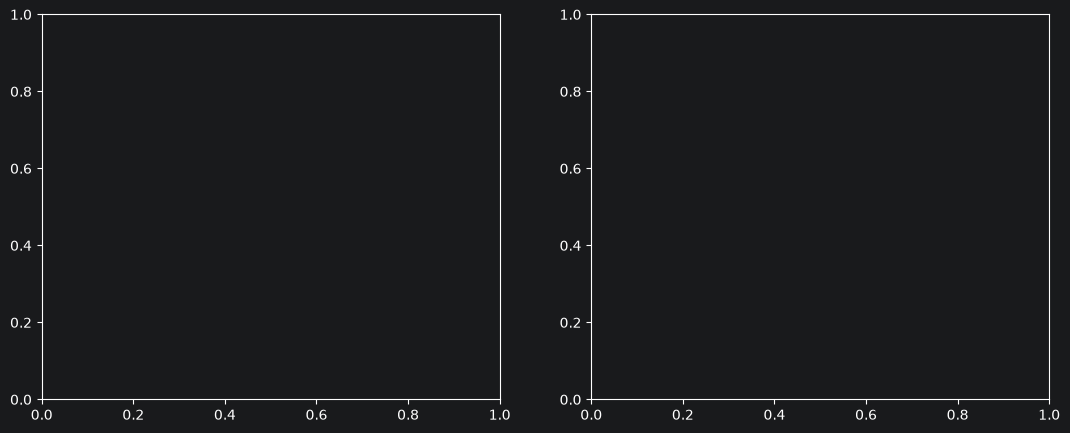

In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Colori categoriali: assegnazione fissa per categoria, non per rango/valore
CATEGORY_COLORS = {
    "Genuine":       "#2a78d6",  # blue
    "Off-topic":     "#1baf7a",  # aqua
    "Informational": "#eda100",  # yellow
    "Pro-AI":        "#008300",  # green
    "Anti-AI":       "#e34948",  # red
}
MUTED_GRID  = "#e1e0d9"
MUTED_TEXT  = "#898781"
PRIMARY_INK = "#0b0b0b"

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Composizione del bucket Neutral ---
ax = axes[0]
composition_sorted = neutral_composition_pct.sort_values(ascending=True)
bar_colors = [CATEGORY_COLORS.get(label, MUTED_TEXT) for label in composition_sorted.index]

bars = ax.barh(composition_sorted.index, composition_sorted.values, color=bar_colors, height=0.6)
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in composition_sorted.values], padding=4, color=PRIMARY_INK, fontsize=9)
ax.set_xlabel("% del bucket 'Neutral'", color=MUTED_TEXT)
ax.set_title(f"Composizione del bucket Neutral (n={len(neutral_bucket)})", color=PRIMARY_INK, loc="left")
ax.set_xlim(0, max(composition_sorted.values) * 1.25)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color(MUTED_GRID)
ax.tick_params(colors=MUTED_TEXT)
ax.xaxis.grid(True, color=MUTED_GRID, linewidth=0.8)
ax.set_axisbelow(True)

# --- Matrice di confusione modello vs annotazione umana ---
ax = axes[1]
confusion = pd.crosstab(y_human, y_model).reindex(index=STANCE_LABELS, columns=STANCE_LABELS, fill_value=0)
seq_blue = LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
)

im = ax.imshow(confusion.values, cmap=seq_blue)
ax.set_xticks(range(len(STANCE_LABELS)), labels=STANCE_LABELS, color=MUTED_TEXT)
ax.set_yticks(range(len(STANCE_LABELS)), labels=STANCE_LABELS, color=MUTED_TEXT)
ax.set_xlabel("Etichetta del modello (LLM)", color=MUTED_TEXT)
ax.set_ylabel("Etichetta umana (ground truth)", color=MUTED_TEXT)
ax.set_title(f"Accordo modello-umano (acc={accuracy:.2f}, F1={macro_f1:.2f})", color=PRIMARY_INK, loc="left")

for i in range(len(STANCE_LABELS)):
    for j in range(len(STANCE_LABELS)):
        value = confusion.values[i, j]
        text_color = "white" if value > confusion.values.max() / 2 else PRIMARY_INK
        ax.text(j, i, str(value), ha="center", va="center", color=text_color)

plt.tight_layout()
plt.show()

## Risultati dell'Analisi Qualitativa
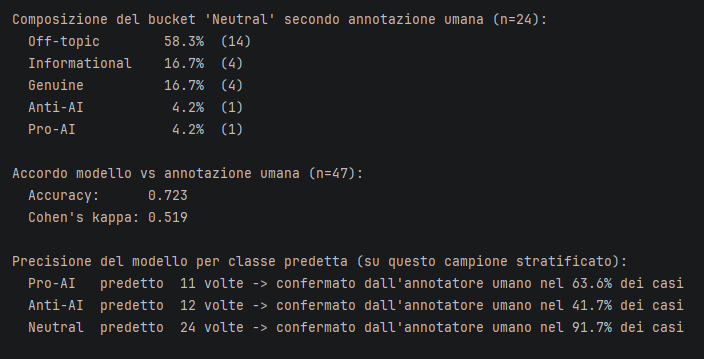

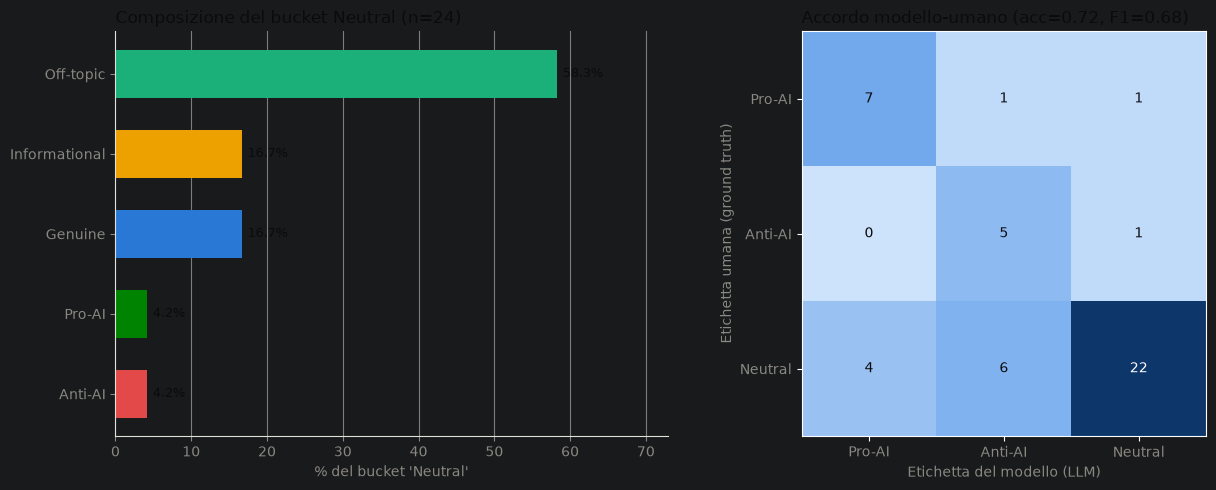

### Il bucket "Neutral" non ben rappresentato

Sui 24 commenti annotati all'interno del bucket "Neutral" del modello:

| Categoria umana               | %     | n   |
| ----------------------------- | ----- | --- |
| Off-topic                     | 58,3% | 14  |
| Informational                 | 16,7% | 4   |
| Genuine (neutralità vera)     | 16,7% | 4   |
| Anti-AI (etichetta sbagliata) | 4,2%  | 1   |
| Pro-AI (etichetta sbagliata)  | 4,2%  | 1   |

Solo **1 commento su 6** classificato "Neutral" dal modello LLM è una neutralità genuina nel senso inteso dalla definizione originale (l'autore pesa pro e contro senza schierarsi) rispetto alla scelta del classificatore umano.
La maggioranza assoluta (58,3%) è in realtà **off-topic**: commenti che compaiono sotto un post AI-related ma non parlano affatto di AI.
Un altro 16,7% è puramente **informativo** (fatti/spiegazioni senza giudizio), e un ulteriore 8,4% sono in realtà commenti con una stance chiara (Pro o Anti) che il modello ha etichettato erroneamente come Neutral, molto probabilmente dovuti all'assenza di riferimenti diretti a AI e tools che vengono invece ereditati dal contesto del post.

Questo conferma il sospetto che aveva motivato la validazione: il tasso di "Neutral" al 73,6% osservato nella prima run **non riflette un'opinione pubblica realmente equilibrata verso l'AI**, ma in larga parte un modello che usa "Neutral" come cestino residuale per tutto ciò che non riconosce come chiaramente Pro o Anti.
Motivo per cui la tassonomia è stata poi ampliata a 6 etichette (Step 3), introducendo `Off-topic`, `Informational` e `No Stance` come categorie esplicite invece di farle confluire tutte in `Neutral`.

### Accordo modello-umano: accuracy, recall e F1

Dalla stessa matrice di confusione mostrata sopra (n=47: 9 commenti umanamente Pro-AI, 6 Anti-AI, 32 Neutral):

- **Accuracy: 0,723**: ma non deve essere presa come assoluta per l'itero dataset: il campione è stratificato sull'etichetta del modello, questo numero è più vicino a una precision media per classe che a un'accuracy reale sull'intero dataset.
- **Macro F1: 0,681**: media semplice tra le F1 delle tre classi. Rappresenta il miglior numero per riassumere la qualità del classificatore in un colpo solo: indica una tenuta discreta ma non solida.

La differenza tra accuracy (0,723) e macro F1 (0,681) segnala che una parte dell'accuracy grezza è "gonfiata" dalla classe maggioritaria (Neutral).

### La qualità varia moltissimo per classe

| Etichetta | Precision | Recall | F1    |
| --------- | --------- | ------ | ----- |
| Pro-AI    | 63,6%     | 77,8%  | 0,700 |
| Anti-AI   | 41,7%     | 83,3%  | 0,556 |
| Neutral   | 91,7%     | 68,8%  | 0,786 |

- **Neutral** ha la F1 più alta (0,786), trainata da una precision molto elevata (91,7%), ma questo è in parte ingannevole: nella versione a 3 classi usata per questa validazione "Neutral" era l'unica opzione disponibile sia per i commenti genuinamente neutrali sia per quelli off-topic o informativi, quindi il modello non classifica realmente una stance "Neutrale Genuina". La recall più bassa (68,8%) mostra inoltre che il modello perde comunque 10 dei 32 commenti umanamente Neutral, etichettandoli come Pro-AI o Anti-AI.
- **Pro-AI** ha un profilo bilanciato (precision 63,6%, recall 77,8%, F1 0,700): il modello individua la maggior parte dei commenti realmente Pro-AI, ma quando dichiara "Pro-AI" ha torto quasi una volta su tre (quasi sempre confondendolo con Neutral, mai con Anti-AI).
- **Anti-AI** è il punto più debole (F1 0,556): la recall è alta (83,3%, il modello individua quasi tutti i commenti realmente ostili all'AI) ma la precision crolla al 41,7%: **più della metà** delle volte in cui il modello etichetta un commento come Anti-AI, l'umano non prende la stessa scelta.

### Nessuna inversione di polarità

Guardando la matrice di confusione, gli errori del modello vanno quasi sempre **verso Neutral**.
Il modello raramente "capisce il contrario" di ciò che l'autore intende; il problema principale, coerente con la bassa precision di Anti-AI, è la sovra-classificazione di commenti ambigui/off-topic/critici ma non anti-AI dentro le classi polarizzate o Neutral.

### Implicazioni per il resto dell'analisi

Questi risultati confermano che la stance analysis a 3 classi, presa alla lettera, avrebbe sovrastimato sia la quota di indecisione reale del pubblico (Neutral gonfiato da off-topic/informational) sia, in misura minore, l'ostilità verso l'AI (Anti-AI con precision solo al 41,7% e F1 0,556, la più bassa delle tre classi). La riclassificazione con il prompt e la tassonomia a 6 etichette (Step 3 aggiornato) mira proprio a correggere queste due distorsioni separando esplicitamente il rumore (Off-topic, Informational, No Stance) dalla stance vera e propria, e fornendo al modello definizioni più operative per ridurre i falsi positivi su Anti-AI.
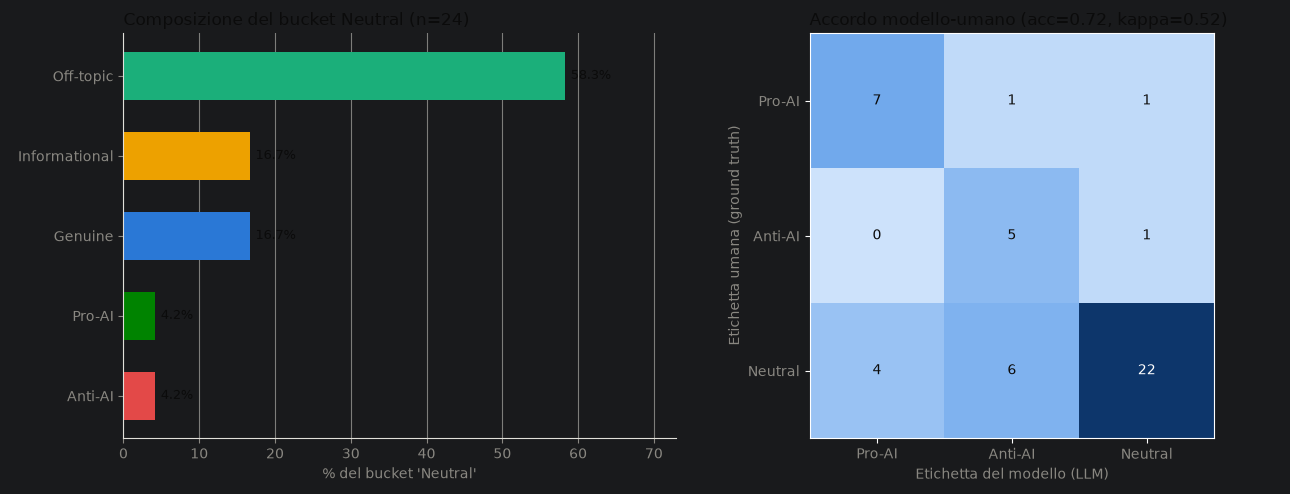
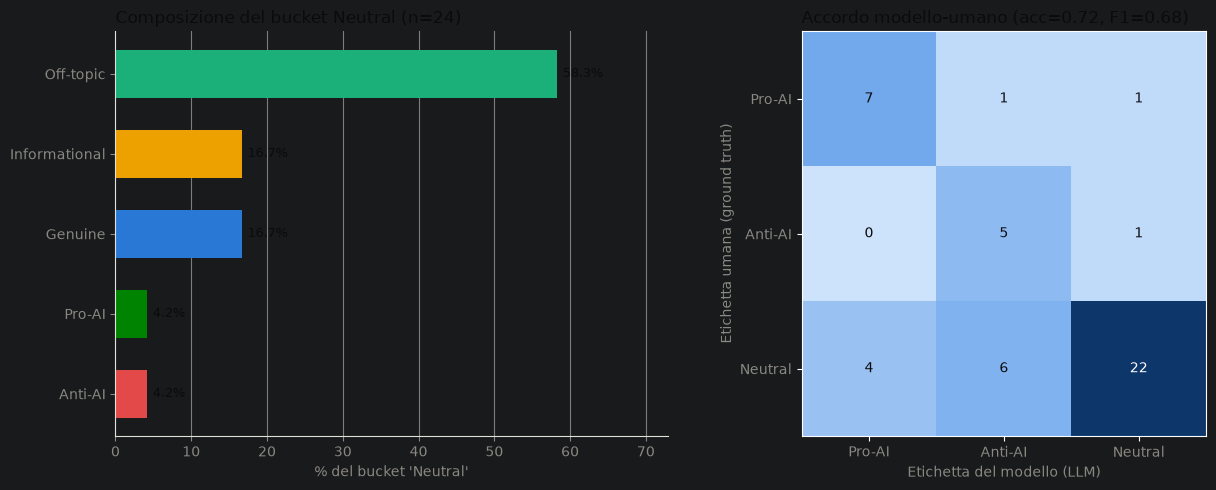

In [5]:
# Recupero dei Risultati della Stance Analysis

OUTPUT_COMMENTS  = "../data/comments_with_stance.csv"
df_output = pd.read_csv(OUTPUT_COMMENTS)

# Step 4: Analisi delle community professionali
Si procede con l'analisi delle community professionali, attraverso la quale si vuole rispondere alle domande di ricerca RQ1, RQ2 e RQ3.
Il processo di analisi vedrà un procedimento che punta a rispondere alle domande in maniera analitica e quantitativa, andando a verificare la composizione dei dati classificati tramite tassonomia a 6 classi, l'interpretazione dei risultati e la valutazione delle percezioni basandosi sulla tassonomia a 3 classi.

### RQ1
La discussione è prevalentemente ottimistica o pessimistica?

### RQ2
Le percezioni cambiano tra professioni?

### RQ3
Chi vede l'AI come minaccia e chi come opportunità?

## Le "Core Labels"
Per poter rispondere adeguatamente alle domande di ricerca è necessario lavorare sulle 3 classi principali Pro-AI, Anti-AI e Neutral, questo perché sono quelle che rappresentano una vera e propria presenza di posizione sull'argomento dell'AI.
Questo non esclude l'analisi e l'utilizzo delle classi aggiuntive Off-topic, Informational e No Stance che permettono una migliore interpretazione dei dati.

In [9]:
# Step 4: caricamento dei dati con stance a 6 etichette, prodotti nello Step 3
import numpy as np

df_stance = pd.read_csv("../data/comments_with_stance.csv")

ALL_LABELS  = ["Pro-AI", "Anti-AI", "Neutral", "Off-topic", "Informational", "No Stance"]
CORE_LABELS = ["Pro-AI", "Anti-AI", "Neutral"]  # le uniche 3 su cui erano formulate le RQ originali

# Distribuzione completa (tutte le 6 etichette) per subreddit, in percentuale sul totale dei commenti
full_counts = pd.crosstab(df_stance["subreddit"], df_stance["stance"]).reindex(columns=ALL_LABELS, fill_value=0)
full_pct    = (full_counts.div(full_counts.sum(axis=1), axis=0) * 100).round(1)

print(f"Commenti totali analizzati: {len(df_stance):,} ({full_counts.sum(axis=1).iloc[0]:,} per subreddit, campione bilanciato dello Step 2)\n")
print("Distribuzione completa a 6 etichette per subreddit (% sul totale dei commenti):")
display(full_pct)

# Quota di commenti che non esprimono alcuna stance vera e propria verso l'AI
noise_share = full_pct[["Off-topic", "Informational", "No Stance"]].sum(axis=1).sort_values(ascending=False)
print("\nQuota di commenti senza stance verso l'AI (Off-topic + Informational + No Stance), per subreddit:")
for sub, pct in noise_share.items():
    print(f"  r/{sub:<15} {pct:>5.1f}%")


Commenti totali analizzati: 15,708 (2,618 per subreddit, campione bilanciato dello Step 2)

Distribuzione completa a 6 etichette per subreddit (% sul totale dei commenti):


stance,Pro-AI,Anti-AI,Neutral,Off-topic,Informational,No Stance
subreddit,,,,,,
ArtistLounge,4.4,16.8,39.0,20.0,12.2,7.7
AskProgramming,7.3,9.1,40.4,8.7,26.8,7.6
copywriting,10.2,14.0,39.7,10.2,18.1,7.8
graphic_design,7.2,14.7,38.6,17.6,14.4,7.6
marketing,10.8,10.3,38.8,13.6,17.7,8.7
webdev,7.8,8.4,39.0,14.0,21.6,9.1



Quota di commenti senza stance verso l'AI (Off-topic + Informational + No Stance), per subreddit:
  r/webdev           44.7%
  r/AskProgramming   43.1%
  r/marketing        40.0%
  r/ArtistLounge     39.9%
  r/graphic_design   39.6%
  r/copywriting      36.1%


### L'Ausilio e Utilità della Tassonomia a 6 etichette

Con la tassonomia a 6 etichette è possibile osservare la quota di "rumore" (Off-topic + Informational + No Stance) per ogni subreddit.
Si nota che questa varia sensibilmente da subreddit a subreddit, dal 36,1% di r/copywriting al 44,7% di r/webdev.

Per questo motivo è necessario normalizzare le percentuali: se le percentuali Pro/Anti/Neutral venissero calcolate direttamente sul totale dei commenti, le community con più rumore risulterebbero artificialmente più "neutrali" o meno polarizzate, non perché i loro utenti abbiano opinioni relamente più neutrali sull'AI, ma perché in quella community si discute proporzionalmente di più di argomenti off-topic o si scambiano più informazioni fattuali (è il caso di r/AskProgramming e r/webdev, dove rispondere con una spiegazione tecnica è più frequente rispetto a esprimere un giudizio personale).

Per rispondere correttamente alle RQ è quindi necessario **rinormalizzare le percentuali** Pro-AI/Anti-AI/Neutral sui soli commenti che esprimono effettivamente una stance, **escludendo Off-topic, Informational e No Stance**, di modo da non confondere l'interpretazione "il subreddit non prende posizione sull'AI" con "il subreddit non ne sta parlando in quel commento".

In [10]:
# Percentuali "core" (Pro-AI / Anti-AI / Neutral), rinormalizzate sui soli commenti con stance (esclude Off-topic/Informational/No Stance)
core_counts = full_counts[CORE_LABELS]
core_totals = core_counts.sum(axis=1)
core_pct    = (core_counts.div(core_totals, axis=0) * 100).round(1)
core_pct["n_stance_bearing"] = core_totals

# Sentiment netto: quanto pesa il Pro-AI rispetto all'Anti-AI in ciascuna community
core_pct["net_sentiment (Pro-Anti)"] = (core_pct["Pro-AI"] - core_pct["Anti-AI"]).round(1)
core_pct = core_pct.sort_values("net_sentiment (Pro-Anti)", ascending=False)

print("Percentuali core per subreddit, rinormalizzate sui soli commenti con stance:")
display(core_pct)

# Aggregato complessivo su tutti i subreddit
overall_core = core_counts.sum(axis=0)
overall_pct  = (overall_core / overall_core.sum() * 100).round(1)
overall_net  = round(overall_pct["Pro-AI"] - overall_pct["Anti-AI"], 1)

print(f"\nAggregato su tutti i subreddit (n={int(overall_core.sum()):,} commenti con stance su {len(df_stance):,} totali):")
for label in CORE_LABELS:
    print(f"  {label:<8} {overall_pct[label]}%")
print(f"\nSentiment netto complessivo (Pro - Anti): {overall_net} punti percentuali")


Percentuali core per subreddit, rinormalizzate sui soli commenti con stance:


stance,Pro-AI,Anti-AI,Neutral,n_stance_bearing,net_sentiment (Pro-Anti)
subreddit,,,,,
marketing,18.1,17.2,64.7,1570,0.9
webdev,14.1,15.3,70.6,1447,-1.2
AskProgramming,12.8,16.1,71.1,1488,-3.3
copywriting,15.9,21.9,62.2,1673,-6.0
graphic_design,11.9,24.3,63.8,1582,-12.4
ArtistLounge,7.2,27.9,64.8,1573,-20.7



Aggregato su tutti i subreddit (n=9,333 commenti con stance su 15,708 totali):
  Pro-AI   13.4%
  Anti-AI  20.6%
  Neutral  66.1%

Sentiment netto complessivo (Pro - Anti): -7.2 punti percentuali


In [64]:
# Setup Colori per plotting

import matplotlib.pyplot as plt

STANCE_COLORS = {
    "Pro-AI":        "#008300",
    "Anti-AI":       "#e34948",
    "Neutral":       "#2a78d6",
    "Off-topic":     "#1baf7a",
    "Informational": "#eda100",
    "No Stance":     "#898781",
}
MUTED_GRID  = "#e1e0d9"
MUTED_TEXT  = "#898781"
PRIMARY_INK = "#edebec"

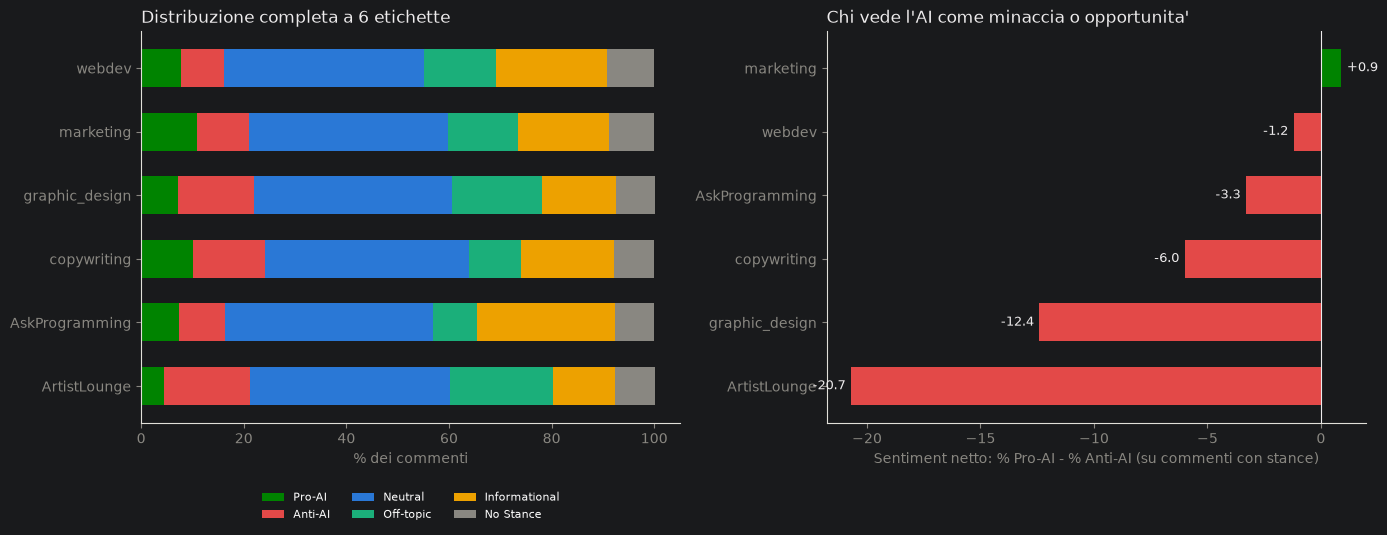

In [63]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Distribuzione completa a 6 etichette, stacked bar per subreddit ---
ax = axes[0]
subs_order = full_pct.index  # ordine alfabetico, indipendente dal sentiment
left = pd.Series(0.0, index=subs_order)
for label in ALL_LABELS:
    values = full_pct.loc[subs_order, label]
    ax.barh(subs_order, values, left=left, color=STANCE_COLORS[label], label=label, height=0.6)
    left += values
ax.set_xlabel("% dei commenti", color=MUTED_TEXT)
ax.set_title("Distribuzione completa a 6 etichette", color=PRIMARY_INK, loc="left")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False, fontsize=8)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color(MUTED_GRID)
ax.tick_params(colors=MUTED_TEXT)

# --- Sentiment netto (Pro - Anti), sui soli commenti con stance ---
ax = axes[1]
net_sorted = core_pct["net_sentiment (Pro-Anti)"].sort_values()
bar_colors = [STANCE_COLORS["Pro-AI"] if v >= 0 else STANCE_COLORS["Anti-AI"] for v in net_sorted.values]
bars = ax.barh(net_sorted.index, net_sorted.values, color=bar_colors, height=0.6)
ax.bar_label(bars, labels=[f"{v:+.1f}" for v in net_sorted.values], padding=4, color=PRIMARY_INK, fontsize=9)
ax.axvline(0, color=PRIMARY_INK, linewidth=0.8)
ax.set_xlabel("Sentiment netto: % Pro-AI - % Anti-AI (su commenti con stance)", color=MUTED_TEXT)
ax.set_title("Chi vede l'AI come minaccia o opportunita'", color=PRIMARY_INK, loc="left")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color(MUTED_GRID)
ax.tick_params(colors=MUTED_TEXT)

plt.tight_layout()
plt.show()


### Rumore Campionario e Correlazione tra Stance e Professione

Prima di trarre conclusioni per RQ2 va verificato che le percentuali ricavate non siano dovute al caso, introdotto con il campionamento (Step 2).
Il **test del chi-quadrato di indipendenza** tra subreddit e stance permette di effettuare inferenza sulla correlazione tra subreddit e stance, permettendo così di rispondere in maniera corretta alle domande di ricerca.

**Ipotesi e statistica test.** Si costruisce una tabella di contingenza subreddit × stance: in ogni cella si contano i commenti osservati (O).
Sotto l'ipotesi nulla `H0: "subreddit e stance sono indipendenti"`, la **frequenza attesa** in ogni cella è data da `E = (totale di riga × totale di colonna) / N`, cioè quella che si osserverebbe se ogni subredditla stessa distribuzione marginale complessiva in ogni subreddit, qualunque essa sia (es. se nel dataset totale il 70% dei commenti è "pro", ci si aspetta che ogni subreddit replichi 70% di "pro")

La statistica test somma lo scarto quadratico relativo su tutte le celle:

```
chi2 = sum( (O - E)^2 / E )
```

Rifiutare l'ipotesi H0 permetterebbe di affermare che subreddit e stance sono associati, e che quindi le popolazioni dei subreddit potrebbero star ricevendo un'influenza sulla stance da parte del subreddit stesso.


In [12]:
from scipy.stats import chi2_contingency

def chi2_summary(counts: pd.DataFrame, name: str):
    """Esegue il test del chi-quadrato di indipendenza"""
    chi2, p, dof, expected = chi2_contingency(counts)
    n = counts.values.sum()
    print(f"[{name}] chi2={chi2:.2f}  dof={dof}  p={p:.2e}  n={n:,}")
    return chi2, p, dof, expected

print("Test del chi-quadrato: subreddit x stance\n")
chi2_core, p_core, dof_core, expected_core = chi2_summary(core_counts, "3 etichette core")

# Residui standardizzati (Pearson): quali celle (subreddit, stance) si discostano di piu'
# dall'indipendenza, e in che direzione. |z| > 1.96 ~ deviazione significativa al 95%
residuals = ((core_counts - expected_core) / np.sqrt(expected_core)).round(2)
print("\nResidui standardizzati subreddit x stance core (|z|>1.96 = deviazione significativa dall'indipendenza):")
display(residuals)


Test del chi-quadrato: subreddit x stance

[3 etichette core] chi2=194.28  dof=10  p=2.51e-36  n=9,333

Residui standardizzati subreddit x stance core (|z|>1.96 = deviazione significativa dall'indipendenza):


stance,Pro-AI,Anti-AI,Neutral
subreddit,,,
ArtistLounge,-6.63,6.42,-0.60
AskProgramming,-0.55,-3.84,2.39
copywriting,2.84,1.23,-1.96
graphic_design,-1.61,3.25,-1.09
marketing,5.13,-2.95,-0.66
webdev,0.77,-4.44,2.14


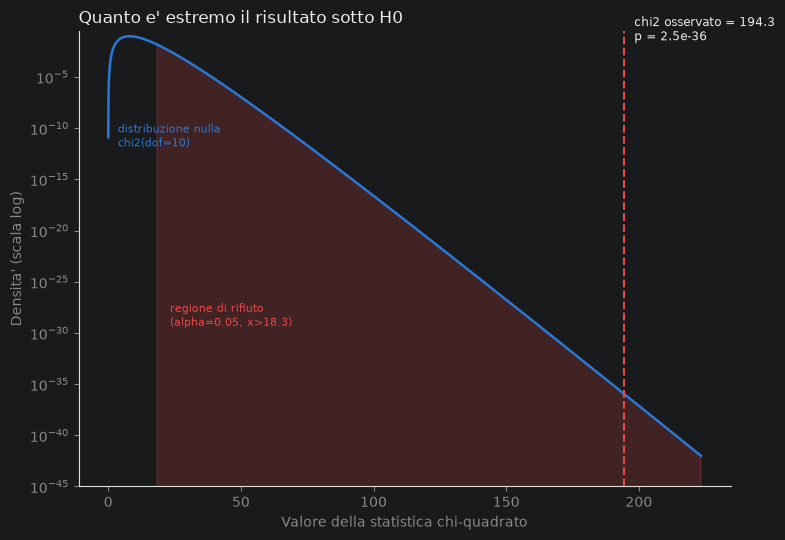

In [65]:
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Distribuzione nulla del chi-quadrato, con la statistica osservata marcata.
# Visualizza direttamente il p-value: l'area rossa e' la probabilita' di superare
# il valore critico per caso; il chi2 osservato cade ben oltre quell'area.
fig, ax = plt.subplots(figsize=(8, 5.5))

crit_val = chi2.ppf(0.95, dof_core)
x = np.linspace(0.01, chi2_core * 1.15, 2000)
y = chi2.pdf(x, dof_core)
ax.plot(x, y, color="#2a78d6", linewidth=1.8)
ax.fill_between(x[x >= crit_val], y[x >= crit_val], color="#e34948", alpha=0.2)
ax.axvline(chi2_core, color="#e34948", linewidth=1.5, linestyle="--")
ax.text(0.06, 0.8, f"distribuzione nulla\nchi2(dof={dof_core})", transform=ax.transAxes,
        color="#2a78d6", fontsize=8, va="top")
ax.text(crit_val + 5, 5e-30, f"regione di rifiuto\n(alpha=0.05, x>{crit_val:.1f})", color="#e34948", fontsize=8)
ax.text(chi2_core + 4, y.max() * 0.4, f"chi2 osservato = {chi2_core:.1f}\np = {p_core:.1e}",
        color=PRIMARY_INK, fontsize=8.5, ha="left")
ax.set_yscale("log")
ax.set_ylim(1e-45, y.max() * 3)
ax.set_xlabel("Valore della statistica chi-quadrato", color=MUTED_TEXT)
ax.set_ylabel("Densita' (scala log)", color=MUTED_TEXT)
ax.set_title("Quanto e' estremo il risultato sotto H0", color=PRIMARY_INK, loc="left")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color(MUTED_GRID)
ax.tick_params(colors=MUTED_TEXT)

plt.tight_layout()
plt.show()


## Risultati: percezione dell’AI nelle community professionali

### RQ1: La discussione è prevalentemente ottimistica o pessimistica?

Aggregando tutti i subreddit, tra i commenti che esprimono davvero una stance verso l'AI (n=9.333, il 59,4% del totale):

| Stance | % |
|---|---|
| Neutral | 66,1% |
| Anti-AI | 20,6% |
| Pro-AI | 13,4% |

Il sentiment netto complessivo (Pro - Anti) è **-7,2 punti percentuali**: la discussione pende verso il pessimismo, ma non in modo travolgente.
L'elemento più rilevante è dunque non tanto la presenza di polarizzazione di opinioni, quanto la sua assenza: il 66,1% dei commenti restano genuinamente ambivalenti, questo ci sta a significare che l'opinione di professionisti sull'AI è propensa a prendere posizioni caute o miste, con solamente una minoranza di opinioni nettamente critiche oppure entusiate.

### RQ2: Le percezioni cambiano tra professioni?

Sì, e il test del chi-quadrato conferma che la differenza non è casuale e dovuta al campionamento, ma che il fenomeno si verifica sulle intere popolazioni dei subreddit e quindi che le stance osservate sono associate alle professioni dello specifico subreddit.

### RQ3: Chi vede l'AI come minaccia e chi come opportunità?

Ordinando i subreddit per sentiment netto (% Pro-AI - % Anti-AI, sui soli commenti con stance):

| Subreddit | Pro-AI | Anti-AI | Neutral | Sentiment netto |
|---|---|---|---|---|
| r/marketing | 18,1% | 17,2% | 64,7% | +0,9 |
| r/webdev | 14,1% | 15,3% | 70,6% | -1,2 |
| r/AskProgramming | 12,8% | 16,1% | 71,1% | -3,3 |
| r/copywriting | 15,9% | 21,9% | 62,2% | -6,0 |
| r/graphic_design | 11,9% | 24,3% | 63,8% | -12,4 |
| r/ArtistLounge | 7,2% | 27,9% | 64,8% | -20,7 |

Emerge un pattern coerente con la natura del lavoro di ciascuna professione: le community il cui output primario è **visivo/creativo** (`r/ArtistLounge`, `r/graphic_design`) si dimostrano più marcatamente _Anti-AI_, quasi certamente perché gli strumenti generativi di immagini (Midjourney, Stable Diffusion) minacciano di sostituire il prodotto del loro lavoro, non solo di velocizzarlo.

All'estremo opposto, `r/marketing` è l'unica community con sentiment netto leggermente positivo, in quanto, a differenza delle professioni creative, vedono nell'AI uno strumento utile all'ottimizzazione del proprio lavoro, piuttosto che la sua sostituzione.

Mentre le due community più **tecniche** (`r/webdev`, `r/AskProgramming`) restano vicine allo zero ma con la quota di _Neutral_ più alta (oltre il 70%): per chi scrive codice l'AI (Copilot, ChatGPT) sembra percepita più come uno strumento di supporto al workflow che come una minaccia diretta all'identità professionale, coerentemente con la quota di "Informational" più alta osservata in queste due community (rispettivamente 26,8% e 21,6%).

# Step 5: Costruzione delle reti e analisi di community detection

## Obiettivo
Gli step precedenti restituiscono una stance individuale per ciascun utente, ma non dicono nulla su **come questi utenti siano connessi tra loro**.
Per rispondere alle domande di ricerca RQ4 e RQ5 è necessario analizzare la **struttura delle relazioni** che si forma tra *opinioni* (RQ4) e tra *professioni* (RQ5), serve quindi creare una **rete**, sulla quale poter misurare fenomeni collettivi come la segregazione o la mescolanza tra gruppi.

Questo step si pone tre obiettivi concreti, in ordine:
1. **Costruire** una rappresentazione a rete delle interazioni tra utenti, definendo come interazione la co-partecipazione ai post (Sezione 1).
2. **Misurare tramite l'assortatività** la tendenza globale della rete a segregarsi per stance (Sezione 2).
3. **Individuare le community** che compongono la rete, per capire se l'assortatività globale nasconde bolle localizzate, gruppi misti o ponti tra fazioni opposte (Sezione 3).

L'assortatività fornisce un giudizio globale ma cieco alla struttura interna della rete, mentre la community detection rivela la struttura ma non quantifica da sola la sua polarizzazione complessiva.
La loro combinazione (vedi tabella comparativa più avanti) permette di distinguere scenari precisi

## 1. Costruzione della Rete

### Rete Bipartita

| Layer  | Tipo          | Attributi                                                                                                 |
| ------ | ------------- | --------------------------------------------------------------------------------------------------------- |
| Attori | Utenti Reddit | username, professione (dal subretddit prevalente oppure da subreddit inizila con approssimazione), stance |
| Gruppi | Post Reddit   | post_id, subreddit, titolo                                                                                |


### Proiezione su Attori (Utenti)
La scelta della proiezioni sugli Utenti deriva dall'obiettivo della ricerca che sceglie come oggetto d'interesse gli utenti più che i post.
Si vuole infatti comprendere il posizionamento di pensieri e opinioni degli utenti con diverse caratteristiche in una rete sociale.

Archi, dopo la proiezione:
- Arco (U1 --> U2): esiste se U1 e U2 hanno commentato almeno un post in comune
- Peso: numero di post in comune (più post in comunie -> maggiore il legame -> maggiore esposizione reciproca)

Degli utenti che condividono più post, quindi che co-partecipano a discussioni sullo stesso tema, rappresentano un legame più significativo di chi condivide uno oppure nessun post.

### Motivazione della Scelta
La rete bipartita permette di rappresentare in maniera naturale la **co-esposizione** degli utenti alle stesse discussioni: formano quindi un legame analizzabile.

Questo permette quindi di effettuare l'analisi necessaria per rispondere alle domande:
- RQ4 (echo-chamber vs cross-pollination): se utenti Pro-AI e Anti-AI co-commentano gli stessi post, c'è esposizione reciproca, si ha un segnale di cross-pollination.
  Se i post attraggono solo commenti Pro-AI oppure Anti-AI, si avrebbe un segnale di echo-chamber.
- RQ5 (gruppi di professioni): la proiezione rivela se professionisti differenti (ad esempio: programmatori e artisti) si trovano nelle stesse discussioni o in bolle separate.

---

## 2. Assortativity

Una volta costruita la rete degli utenti, la prima misura calcolata è l'**assortatività per stance** e per **professione**.
La si calcola per prima in quanto si tratta di un coefficiente poco costoso da calcolare e capace di dare immediatamente un **giudizio complessivo** sulla rete nella sua interezza: è utile sapere se la rete mostra una tendenza generale alla segregazione per stance e professione oppure no.

**L'obiettivo** è quindi stimare, su scala globale, se un utente Pro-AI ha una probabilità maggiore di co-commentare (cioè di comparire sotto lo stesso post) insieme a un altro utente Pro-AI piuttosto che con un utente Anti-AI, e viceversa per gli utenti Anti-AI.
Allo stesso modo si può stimare se un utente è più propenso a co-commentare con utenti della stessa professione oppure con utenti di professioni diverse.

In altre parole, l'assortatività risponde alla domanda "la rete, presa nel suo complesso, tende a polarizzarsi per opinione?", fornendo un primo indizio diretto sulla presenza di **echo-chamber** (RQ4): un valore alto indica una tendenza sistemica degli utenti a esporsi solo a chi condivide la propria posizione, un valore basso o negativo indica invece che l'esposizione reciproca tra stance opposte è comune.
Aiuta anche a comprendere se le discussioni sono **mescolate** oppure **segregate** tra gruppi di utenti con professioni diverse.

### Valori interpretati:
| Assortativity | Significato                                                                                                           |
| ------------- |-----------------------------------------------------------------------------------------------------------------------|
| = +1          | Perfetta assortatività: nessuna interazione tra comunità opposte                                                      |
| 0             | Casuale: connessioni indipendenti dalla stance o professione                                                          |
| -1            | Disassortività massima: interazioni principalmente tra comunità simili |

Va però sottolineato un limite intrinseco di questa misura: l'assortatività è un indice **globale**, non locale.
Un valore vicino allo zero, ad esempio, è compatibile sia con una rete realmente priva di struttura, sia con una rete che contiene diverse bolle interne fortemente polarizzate ma di segno opposto, che si "cancellano" a vicenda nella media globale.
Per questo motivo l'assortatività da sola non è sufficiente a rispondere alle domande di ricerca: serve un secondo strumento capace di scendere a livello locale e mostrare *dove* e *quante* di queste eventuali bolle esistono, da cui la scelta di affiancarle la community detection (Sezione 3).

---

## 3. Community Detection (Louvain/Leiden)

Se l'assortatività fornisce un giudizio aggregato sull'intera rete, la **community detection** ha l'obiettivo complementare di scomporre la rete in sotto-gruppi concreti (community), permettendo di passare da un singolo numero globale a una mappa locale della struttura della rete.
Questo passaggio è necessario perché solo osservando le community individuate è possibile rispondere a domande che l'assortatività, per costruzione, non può porre: quante bolle distinte esistono, se sono omogenee per stance o per professione, e se esistono nodi o community che fungono da ponte tra fazioni opposte.

Algoritmo:
- **Leiden**

La scelta di Leiden è difesa dalla necessità di garantire che ogni community individuata sia effettivamente ben connessa al suo interno, riducendo la frammentazione in micro-community isolate e fornendo risultati più stabili e più facilmente interpretabili.

Analisi:
  - Quante community emergono?
  - Le community presentano utenti con professioni mischiate o tendono a formare bolle separate?
  - Internamente ad ogni community, gli utenti condividono le stance oppure si mischiano?

Una volta individuate le community, per ciascuna di esse viene calcolata la composizione interna per stance (percentuale di Pro-AI, Anti-AI, Neutral) e per subreddit di provenienza.

### Interpretazione possibile:
La community detection potrebbe rivelare che esistono cluster di utenti con stessa stance e professioni diverse (il che sarebbe forte segnale di echo-chambers di opinioni), altrimenti potrebbe mostrare un comportamento opposto: in cui si hanno cluster di utenti con la stessa professione al cui interno si presentano alcune echo-chamber per le stance, oppure stance completamente mischiate (che sarebbero invece forte segnale di cross-pollination).

Insight reperibili:
1. C'è tendenza globale a clustering per stance?
2. Esistono echo-chamber distinte per stance?
3. Esistono community miste per professione ma omogenea per stance?
4. Le community presentano utenti con professioni mischiate o tendono a formare bolle separate?
4. Chi sono i nodi centrali di ogni cluster?

---

## Output atteso da questo Step:

Su Stance:
- Assortatività stance alta + Community omogenee per stance
  → Echo-chamber forti e diffuse
- Assortatività stance alta + Community miste per stance
  → Impossibile: se le community sono miste, l'assortatività non può essere alta. Segnale di errore metodologico da investigare.
- Assortatività stance bassa + Community omogenee per stance
  → Echo-chamber locali ma non dominanti: esistono bolle ma sono minoritarie. Caso più interessante.
- Assortatività stance bassa + Community miste per stance
  → Cross-pollination diffusa, nessuna bolla dominante.

Su Professioni:
- Assortatività professione alta + community omogenee per professione
  → Bolle completamente separate per professione
- Assortatività professione alta + community miste per professione
  → Bolle separate per professione ma con utenti ponte
-  Assortatività professione bassa + community omogenee per professione
  → Professionisti formano bolle locali, ma discussioni eterogenee globali
-  Assortatività professione bassa + community miste per professione
  → Discussioni mischiate locali, ma assenza di fenomeno globale

In questa maniera è possibile rispondere ad entrambe le domande:
- RQ4 (echo-chambers): "Utenti che condividono *stance* sull'AI creano **echo-chambers** oppure c'è un fenomeno di **cross-pollination**?"
- RQ5 (bolle separate): "Gruppi di professioni differenti condividono discussioni oppure si trovano in bolle separate?"


## 5.1 Preparazione degli attributi utente

Per costruire la rete serve un solo record per utente, con due attributi: la **professione** (approssimata dal subreddit prevalente, come definito sopra) e la **stance dominante** (l'etichetta a 6 classi piu' frequente tra i suoi commenti).

Entrambi gli attributi richiedono un'aggregazione perche' un utente puo' aver commentato piu' volte, anche su subreddit o con stance diverse tra loro. Si verifica quindi quanto questa approssimazione sia forzata:
- **Professione**: se solo una piccola minoranza di utenti commenta in piu' di un subreddit, il subreddit prevalente e' un proxy affidabile.
- **Stance**: e' atteso che piu' commenti dello stesso utente non condividano sempre l'etichetta (es. un commento "Informational" e uno "Neutral" non sono in reale contraddizione). Si usa quindi la moda, con un tie-break deterministico che privilegia le etichette "core" (Pro-AI/Anti-AI/Neutral) su quelle di rumore: in caso di parita' si assume che l'etichetta piu' informativa rifletta meglio la reale posizione dell'utente.

In [44]:
# Step 5.1: attributi per utente (professione dominante + stance dominante)

SUBREDDIT_TO_PROFESSION = {
    "ArtistLounge":   "Artista",
    "AskProgramming": "Programmatore",
    "copywriting":    "Copywriter",
    "graphic_design": "Graphic Designer",
    "marketing":      "Marketer",
    "webdev":         "Web Developer",
}

# Tie-break deterministico: si definisce una priorità di importanza in caso di parità nella decisione della stance dell'utente
STANCE_TIE_BREAK_PRIORITY = ["Pro-AI", "Anti-AI", "Neutral", "Off-topic", "Informational", "No Stance"]

def dominant_label(series, priority):
    """Etichetta piu' frequente in `series`; in caso di parita' vince la prima trovata in `priority`."""
    counts = series.value_counts()
    top_freq = counts.max()
    tied = counts[counts == top_freq].index.tolist()
    for label in priority:
        if label in tied:
            return label
    return tied[0]

# Selezione della 'profession' dominante, il tie-break è il subreddit prevalente
user_profession = (
    df_stance.groupby("author")["subreddit"]
    .apply(lambda s: dominant_label(s, sorted(s.unique())))
    .map(SUBREDDIT_TO_PROFESSION)
)

# Selezione della 'stance' dominante, il tie-break con priority
user_stance = df_stance.groupby("author")["stance"].apply(lambda s: dominant_label(s, STANCE_TIE_BREAK_PRIORITY))

# Quanti utenti sono in più subreddit
n_users = df_stance["author"].nunique()
multi_subreddit_users = (df_stance.groupby("author")["subreddit"].nunique() > 1).sum()
multi_stance_users = (df_stance.groupby("author")["stance"].nunique() > 1).sum()

# Risultati
print(f"Utenti totali: {n_users:,}")
print(f"Utenti attivi in più di un subreddit: {multi_subreddit_users:,} ({multi_subreddit_users / n_users * 100:.2f}%)")
print(f"Utenti con più di un'etichetta di stance tra i loro commenti: {multi_stance_users:,} ({multi_stance_users / n_users * 100:.2f}%)")
print("\nDistribuzione delle professioni (subreddit prevalente):")
print(user_profession.value_counts())


Utenti totali: 10,456
Utenti attivi in più di un subreddit: 204 (1.95%)
Utenti con più di un'etichetta di stance tra i loro commenti: 1,614 (15.44%)

Distribuzione delle professioni (subreddit prevalente):
subreddit
Web Developer       2081
Marketer            1823
Graphic Designer    1808
Artista             1759
Programmatore       1626
Copywriter          1359
Name: count, dtype: int64


## 5.2 Costruzione del grafo bipartito

Si costruisce con la rete bipartita Attori (utenti) <-> Gruppi (post) descritta precedentemente:
- Nodo Attore: attributi `profession` e `stance` calcolati al punto 5.1
- Nodo Gruppo: attributo `subreddit` (un post appartiene a un solo subreddit)
- Arco Attore-Gruppo: presente se l'utente ha commentato il post, con peso pari al numero di commenti dell'utente su quel post (in pratica quasi sempre il peso ha valore 1, dato che i commenti raccolti sono solo di primo livello).

In [45]:
# Step 5.2: costruzione del grafo bipartito Attori (utenti) <-> Gruppi (post)
import networkx as nx

B = nx.Graph()

# Nodi Attori
B.add_nodes_from(user_profession.index, bipartite=0)
nx.set_node_attributes(B, user_profession.to_dict(), "profession")
nx.set_node_attributes(B, user_stance.to_dict(), "stance")

# Nodi Gruppi
post_subreddit = df_stance.groupby("link_id")["subreddit"].first()
B.add_nodes_from(post_subreddit.index, bipartite=1)
nx.set_node_attributes(B, post_subreddit.to_dict(), "subreddit")

# Archi Attore -> Gruppo, peso = numero di commenti dell'utente su quel post
edge_weights = df_stance.groupby(["author", "link_id"]).size()
B.add_weighted_edges_from((u, p, w) for (u, p), w in edge_weights.items())

n_actors = sum(1 for _, d in B.nodes(data=True) if d["bipartite"] == 0)
n_groups = sum(1 for _, d in B.nodes(data=True) if d["bipartite"] == 1)
print(f"Rete bipartita: {n_actors:,} nodi Attore, {n_groups:,} nodi Gruppo, {B.number_of_edges():,} archi")
print(f"Peso medio arco (commenti per coppia utente-post): {edge_weights.mean():.2f} (mediana {edge_weights.median():.0f}) -> valore atteso: 1")


Rete bipartita: 10,456 nodi Attore, 4,106 nodi Gruppo, 15,634 archi
Peso medio arco (commenti per coppia utente-post): 1.00 (mediana 1) -> valore atteso: 1


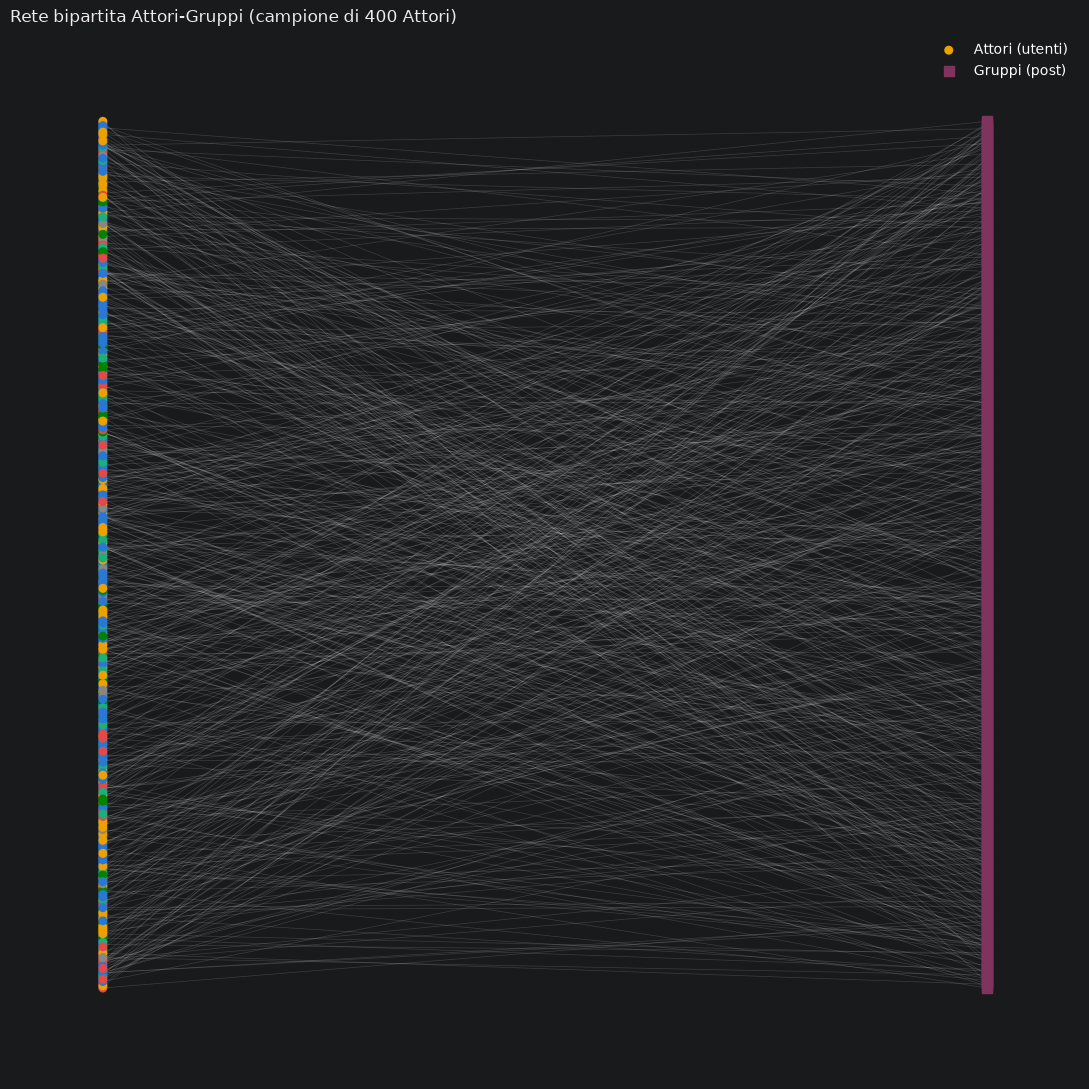

In [66]:
# Step 5.2b: visualizzazione della rete bipartita
import matplotlib.pyplot as plt
import numpy as np

# Sampling dei nodi (per leggibilità)
BIPARTITE_PLOT_SAMPLE = 400

actor_nodes_all = [n for n, d in B.nodes(data=True) if d["bipartite"] == 0]
group_nodes_all = [n for n, d in B.nodes(data=True) if d["bipartite"] == 1]

# Sampling casuale
rng = np.random.RandomState(RANDOM_STATE)

sampled_actors = list(rng.choice(actor_nodes_all, size=min(BIPARTITE_PLOT_SAMPLE, len(actor_nodes_all)), replace=False))
sampled_groups = [n for n in group_nodes_all if any(B.has_edge(n, a) for a in sampled_actors)]

B_sub = B.subgraph(sampled_actors + sampled_groups)

# Plotting della Rete
pos = nx.bipartite_layout(B_sub, sampled_actors)

fig, ax = plt.subplots(figsize=(11, 11))
nx.draw_networkx_edges(B_sub, pos, alpha=0.15, width=0.5, ax=ax, edge_color="#FFFFFF")
nx.draw_networkx_nodes(
    B_sub, pos, nodelist=sampled_actors,
    node_color=[STANCE_COLORS.get(B_sub.nodes[n]["stance"], MUTED_GRID) for n in sampled_actors],
    node_size=30, node_shape="o", label="Attori (utenti)", ax=ax,
)
nx.draw_networkx_nodes(
    B_sub, pos, nodelist=sampled_groups,
    node_color="#80335d", node_size=60, node_shape="s", label="Gruppi (post)", ax=ax,
)

ax.set_title(f"Rete bipartita Attori-Gruppi (campione di {len(sampled_actors)} Attori)", color=PRIMARY_INK, loc="left")
ax.legend(loc="upper right", frameon=False)
ax.axis("off")
plt.tight_layout()
plt.show()

## 5.3 Proiezione sugli utenti

Si proietta la rete bipartita sul solo layer Attori, come motivato nell'introduzione: l'oggetto di interesse della ricerca sono gli utenti, non i singoli post.

Si collegano due utenti se condividono almeno un post e pesa l'arco con il **numero di post in comune**.

Gli utenti il cui unico post commentato non ha altri commentatori restano **isolati** dopo la proiezione: nessuna co-esposizione osservabile, quindi nessuna informazione utile per l'analisi di rete che segue, vengono dunque esclusi da qui in avanti.

In [48]:
# Step 5.3: proiezione bipartita sugli utenti
import numpy as np

actor_nodes = [n for n, d in B.nodes(data=True) if d["bipartite"] == 0]
projected = nx.algorithms.bipartite.weighted_projected_graph(B, actor_nodes)

# Lista di utenti isolati da filtrare dalla rete
isolated_users = list(nx.isolates(projected))
G = projected.copy()
G.remove_nodes_from(isolated_users)

print(f"Rete proiettata (pre-filtro): {projected.number_of_nodes():,} nodi, {projected.number_of_edges():,} archi")
print(f"Utenti isolati esclusi (nessuna co-esposizione): {len(isolated_users):,} ({len(isolated_users) / projected.number_of_nodes() * 100:.1f}%)")
print(f"Rete degli utenti (G): {G.number_of_nodes():,} nodi, {G.number_of_edges():,} archi")

edge_weight_values = [w for _, _, w in G.edges(data="weight")]
print(f"Peso medio arco (post in comune): {np.mean(edge_weight_values):.2f}  |  mediana: {np.median(edge_weight_values):.0f}  |  massimo: {max(edge_weight_values)}")


Rete proiettata (pre-filtro): 10,456 nodi, 93,858 archi
Utenti isolati esclusi (nessuna co-esposizione): 805 (7.7%)
Rete degli utenti (G): 9,651 nodi, 93,858 archi
Peso medio arco (post in comune): 1.01  |  mediana: 1  |  massimo: 7


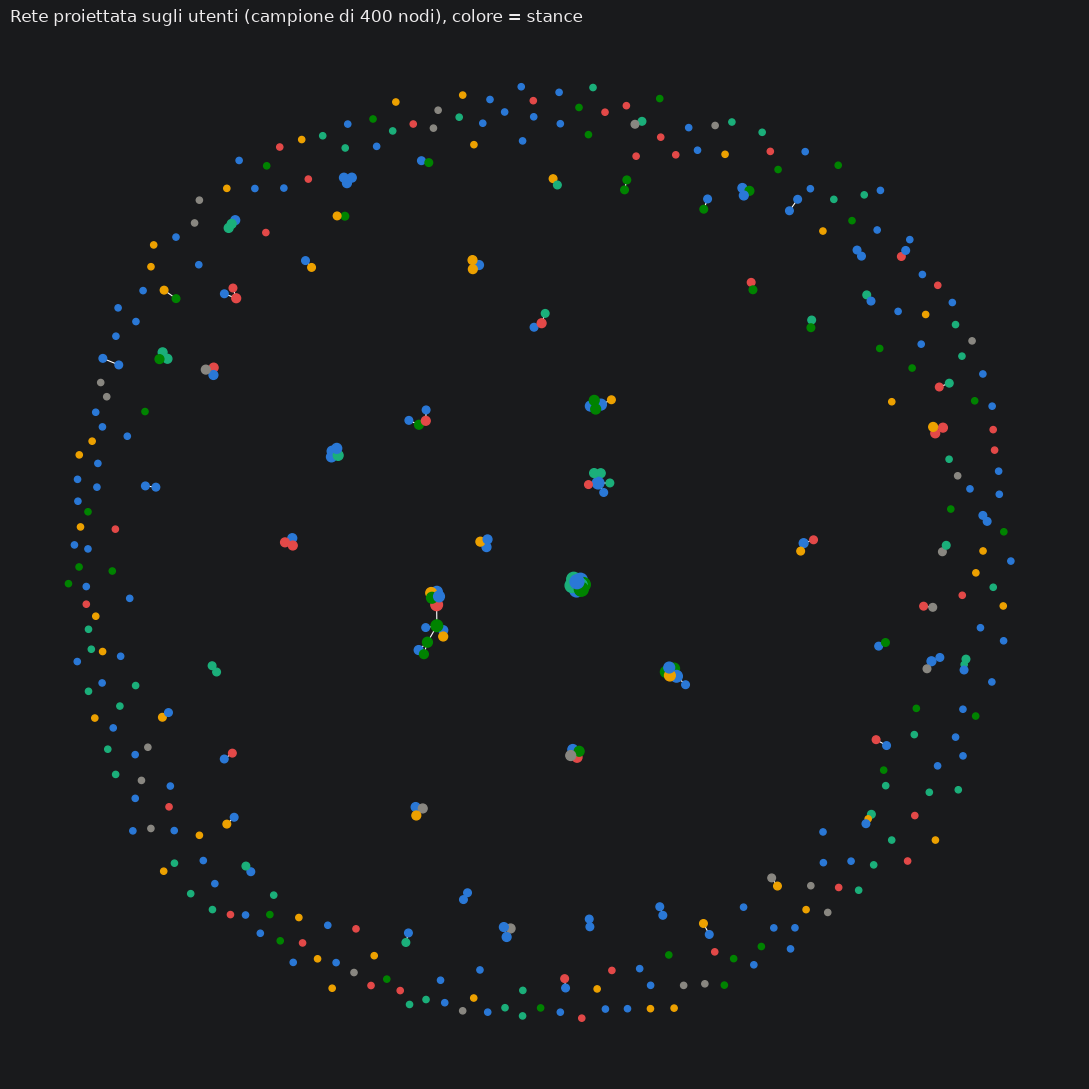

In [67]:
# Step 5.3b: visualizzazione della rete proiettata sugli utenti
import matplotlib.pyplot as plt
import numpy as np

# Sampling dei nodi (per leggibilità)
PROJECTION_PLOT_SAMPLE = 400

# Sampling casuale
rng = np.random.RandomState(RANDOM_STATE)
plot_nodes = list(rng.choice(list(G.nodes()), size=min(PROJECTION_PLOT_SAMPLE, G.number_of_nodes()), replace=False))
G_sub = G.subgraph(plot_nodes)

# Plotting della Rete
pos = nx.spring_layout(G_sub, seed=RANDOM_STATE, weight="weight")

fig, ax = plt.subplots(figsize=(11, 11))
edge_widths = [G_sub[u][v]["weight"] * 0.8 for u, v in G_sub.edges()]
nx.draw_networkx_edges(G_sub, pos, width=edge_widths, alpha=1, ax=ax, edge_color="#FFFFFF")
node_colors = [STANCE_COLORS.get(G_sub.nodes[n].get("stance"), MUTED_GRID) for n in G_sub.nodes()]
node_sizes = [20 + 10 * G_sub.degree(n) for n in G_sub.nodes()]
nx.draw_networkx_nodes(G_sub, pos, node_color=node_colors, node_size=node_sizes, ax=ax)
ax.set_title(f"Rete proiettata sugli utenti (campione di {len(plot_nodes)} nodi), colore = stance", color=PRIMARY_INK, loc="left")
ax.axis("off")
plt.tight_layout()
plt.show()

## 5.4 Esplorazione della rete: componenti connesse e grado

Prima di calcolare assortatività e community detection è utile capire quanto la rete sia frammentata.

Una componente connessa è l'insieme massimale di utenti raggiungibili l'uno dall'altro seguendo catene di "co-commento" non necessariamente sullo stesso post, ma attraverso una sequenza di post condivisi a due a due.
Osservando la rappresentazione del grafo, ci si aspetta di vedere molte piccole componenti isolate: un post con pochi commentatori genera una piccola cricca scollegata dal resto della rete (componenti di dimensione 2).

Numero di componenti connesse: 403
Componente gigante: 8,369 nodi (86.7% della rete)
Componenti di dimensione 2 (coppie isolate dal resto): 233


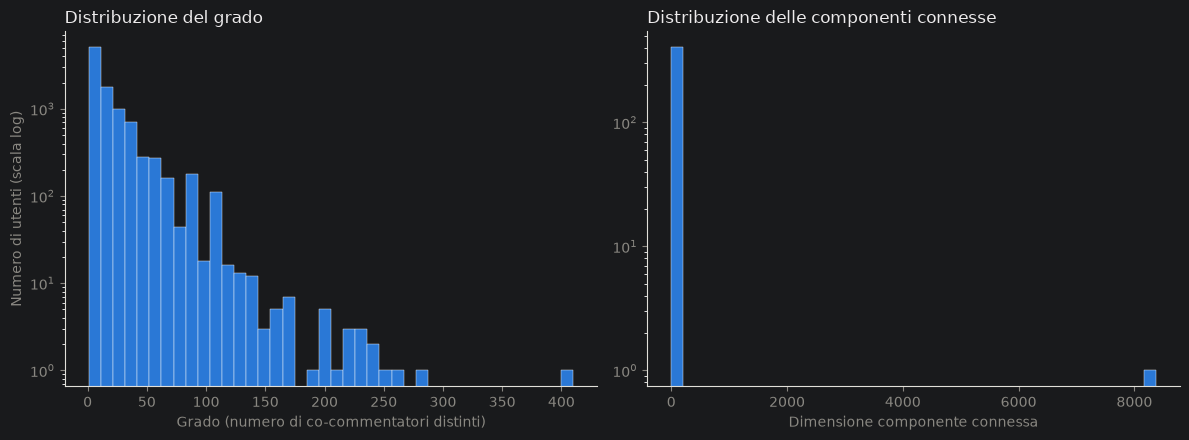

In [68]:
# Step 5.4: componenti connesse e distribuzione del grado
import matplotlib.pyplot as plt

# Si prende la componente più grande
components = sorted(nx.connected_components(G), key=len, reverse=True)
giant = components[0]

print(f"Numero di componenti connesse: {len(components):,}")
print(f"Componente gigante: {len(giant):,} nodi ({len(giant) / G.number_of_nodes() * 100:.1f}% della rete)")
print(f"Componenti di dimensione 2 (coppie isolate dal resto): {sum(1 for c in components if len(c) == 2):,}")

# Gradi dei nodi
degrees = [d for _, d in G.degree()]

# Plotting dei Grafici
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.hist(degrees, bins=40, color=STANCE_COLORS["Neutral"], edgecolor="white", linewidth=0.3)
ax.set_yscale("log")
ax.set_xlabel("Grado (numero di co-commentatori distinti)", color=MUTED_TEXT)
ax.set_ylabel("Numero di utenti (scala log)", color=MUTED_TEXT)
ax.set_title("Distribuzione del grado", color=PRIMARY_INK, loc="left")

ax = axes[1]
comp_sizes = [len(c) for c in components]
ax.hist(comp_sizes, bins=40, color=STANCE_COLORS["Neutral"], edgecolor="white", linewidth=0.3)
ax.set_yscale("log")
ax.set_xlabel("Dimensione componente connessa", color=MUTED_TEXT)
ax.set_title("Distribuzione delle componenti connesse", color=PRIMARY_INK, loc="left")

for ax in axes:
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(MUTED_GRID)
    ax.tick_params(colors=MUTED_TEXT)

plt.tight_layout()
plt.show()


## 5.5 Assortativita' per stance e professione

Si calcola l'assortatività sia per `stance` sia per `profession`, sulla rete `G` (gli utenti isolati esclusi al punto 5.3 non hanno comunque archi, quindi non avrebbero comunque influenzato il risultato).


Assortatività per stance:      +0.056
Assortatività per professione: +0.958


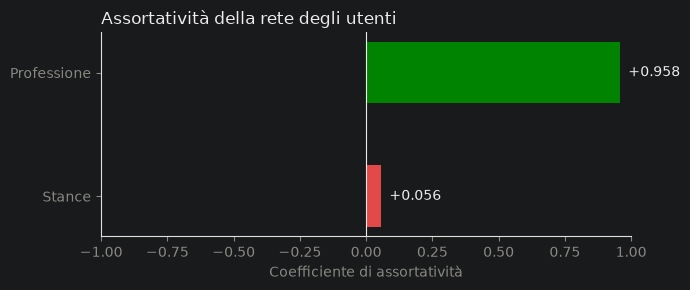

In [69]:
# Step 5.5: assortativita' per stance e per professione

# Si calcola l'assortatività con il metodo di networkx
r_stance = nx.attribute_assortativity_coefficient(G, "stance")
r_profession = nx.attribute_assortativity_coefficient(G, "profession")

print(f"Assortatività per stance:      {r_stance:+.3f}")
print(f"Assortatività per professione: {r_profession:+.3f}")


# Plotting del Risultato
fig, ax = plt.subplots(figsize=(7, 3))
labels = ["Stance", "Professione"]
values = [r_stance, r_profession]
colors = [STANCE_COLORS["Anti-AI"], STANCE_COLORS["Pro-AI"]]
bars = ax.barh(labels, values, color=colors, height=0.5)
ax.bar_label(bars, labels=[f"{v:+.3f}" for v in values], padding=6, color=PRIMARY_INK, fontsize=10)
ax.axvline(0, color=PRIMARY_INK, linewidth=0.8)
ax.set_xlim(-1, 1)
ax.set_xlabel("Coefficiente di assortatività", color=MUTED_TEXT)
ax.set_title("Assortatività della rete degli utenti", color=PRIMARY_INK, loc="left")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color(MUTED_GRID)
ax.tick_params(colors=MUTED_TEXT)
plt.tight_layout()
plt.show()


## 5.6 Community Detection con l'algoritmo di Leiden

Si usa **Leiden** invece di Louvain: Leiden garantisce che ogni community trovata sia internamente ben connessa (Louvain può produrre community disconnesse al suo interno, un difetto noto dell'algoritmo che Leiden corregge).
Per Leiden si deve convertire la rete in un grafo `igraph`.


In [54]:
# Step 5.6: community detection con Leiden (via python-igraph + leidenalg)
import igraph as ig
import leidenalg

# Setup per igraph
node_list = list(G.nodes())
node_index = {node: i for i, node in enumerate(node_list)}
ig_edges = [(node_index[u], node_index[v]) for u, v in G.edges()]
ig_weights = [G[u][v]["weight"] for u, v in G.edges()]

# Creazione del grafo
G_ig = ig.Graph(n=len(node_list), edges=ig_edges)
G_ig.es["weight"] = ig_weights

# Implementazione di Laiden
partition = leidenalg.find_partition(
    G_ig,
    leidenalg.RBConfigurationVertexPartition,
    weights="weight",
    seed=RANDOM_STATE,
)

community_of = {node_list[i]: cid for cid, members in enumerate(partition) for i in members}
nx.set_node_attributes(G, community_of, "community")

community_sizes = pd.Series(community_of).value_counts()
print(f"Community trovate: {len(community_sizes):,}")
print(f"Modularità della partizione: {partition.modularity:.3f}")
print(f"Dimensione community: mediana {community_sizes.median():.0f}, media {community_sizes.mean():.1f}, massima {community_sizes.max():,}")


Community trovate: 441
Modularità della partizione: 0.864
Dimensione community: mediana 2, media 21.9, massima 1,148


## 5.7 Filtraggio delle community e analisi di composizione

Con centinaia di community, molte sono cricche minuscole generate da un singolo post con pochi commentatori (coerente con la frammentazione osservata al punto 5.4).
Si applica quindi una soglia minima `MIN_COMMUNITY_SIZE = 20`, verificando che il filtro sia conservativo (percentuale di rete ancora coperta alta) prima di usarlo.

Per ogni community superstite si calcolano due indici di "purezza":
- **`profession_purity`**: quota della professione più frequente sul totale dei membri.
- **`stance_purity`**: quota della stance "core" (Pro-AI/Anti-AI/Neutral) più frequente, calcolata **solo sui membri con una stance core dominante** (`core_coverage`, si escludono quindi gli utenti la cui etichetta prevalente è di rumore (Off-topic/Informational/No Stance). Altrimenti la metrica misurerebbe quanto rumore c'è in una community invece di quanto sia polarizzata, confondendo due fenomeni diversi. La stessa logica seguita con la rinormalizzazione già usata nello Step 4 per `core_pct`.

In [58]:
# Step 5.7: filtro sulle community e calcolo degli indici di purezza
MIN_COMMUNITY_SIZE = 20

# Creazione del DataFrame con i dati utili
nodes_df = pd.DataFrame({"user": node_list})
nodes_df["community"]  = nodes_df["user"].map(community_of)
nodes_df["profession"] = nodes_df["user"].map(user_profession)
nodes_df["stance"]     = nodes_df["user"].map(user_stance)

# Filtraggio delle community
large_communities = community_sizes[community_sizes >= MIN_COMMUNITY_SIZE].index
covered_share = community_sizes[large_communities].sum() / community_sizes.sum() * 100
print(f"Community con almeno {MIN_COMMUNITY_SIZE} membri: {len(large_communities)} su {len(community_sizes)} ({covered_share:.2f}% della rete coperta)")

# Creazione del df con i dati filtrati
rows = []
for cid, members in nodes_df[nodes_df["community"].isin(large_communities)].groupby("community"):
    size = len(members)
    prof_counts = members["profession"].value_counts()
    core_members = members[members["stance"].isin(CORE_LABELS)]
    if len(core_members):
        stance_counts = core_members["stance"].value_counts()
        dominant_stance, stance_purity = stance_counts.idxmax(), stance_counts.max() / len(core_members)
    else:
        dominant_stance, stance_purity = None, np.nan
    rows.append({
        "community": cid, "size": size,
        "dominant_profession": prof_counts.idxmax(),
        "profession_purity": prof_counts.max() / size,
        "dominant_stance": dominant_stance,
        "stance_purity": stance_purity,
        "core_coverage": len(core_members) / size,
    })

community_stats = pd.DataFrame(rows).sort_values("size", ascending=False).reset_index(drop=True)

# Visualizza il df creato
display(community_stats.head(15).style.format({
    "profession_purity": "{:.1%}", "stance_purity": "{:.1%}", "core_coverage": "{:.1%}",
}))

# Calcolo delle statistiche di purezza sui dati filtrati
weighted_profession_purity = np.average(community_stats["profession_purity"], weights=community_stats["size"])
weighted_stance_purity = np.average(community_stats["stance_purity"].fillna(0), weights=community_stats["size"])
global_core_baseline = (
    df_stance.loc[df_stance["stance"].isin(CORE_LABELS), "stance"].value_counts(normalize=True).max()
)

print(f"\nPurezza media (pesata per dimensione) professione: {weighted_profession_purity:.1%}")
print(f"Purezza media (pesata per dimensione) stance core:   {weighted_stance_purity:.1%}")
print(f"Baseline globale (quota della stance core più frequente, ossia la più probabile): {global_core_baseline:.1%}")


Community con almeno 20 membri: 36 su 441 (86.59% della rete coperta)


,community,size,dominant_profession,profession_purity,dominant_stance,stance_purity,core_coverage
0,0,1148,Artista,97.5%,Neutral,63.8%,68.0%
1,1,1118,Copywriter,94.6%,Neutral,63.3%,68.7%
2,2,1014,Graphic Designer,98.0%,Neutral,60.6%,67.6%
3,3,949,Programmatore,94.4%,Neutral,72.1%,62.7%
4,4,492,Marketer,96.1%,Neutral,62.8%,66.7%
5,5,349,Graphic Designer,97.4%,Neutral,57.7%,63.6%
6,6,230,Web Developer,96.5%,Neutral,63.9%,67.4%
7,7,199,Web Developer,99.5%,Neutral,70.3%,59.3%
8,8,193,Web Developer,96.9%,Neutral,71.8%,64.2%
9,9,175,Marketer,89.1%,Neutral,64.8%,60.0%



Purezza media (pesata per dimensione) professione: 94.6%
Purezza media (pesata per dimensione) stance core:   63.8%
Baseline globale (quota della stance core più frequente, ossia la più probabile): 66.1%


## 5.8 Visualizzazione della composizione delle community principali

I due grafici seguenti mostrano visivamente cosa dicono gli indici di purezza calcolati sopra, per le community più grandi: composizione a 6 etichette per stance e composizione per professione.

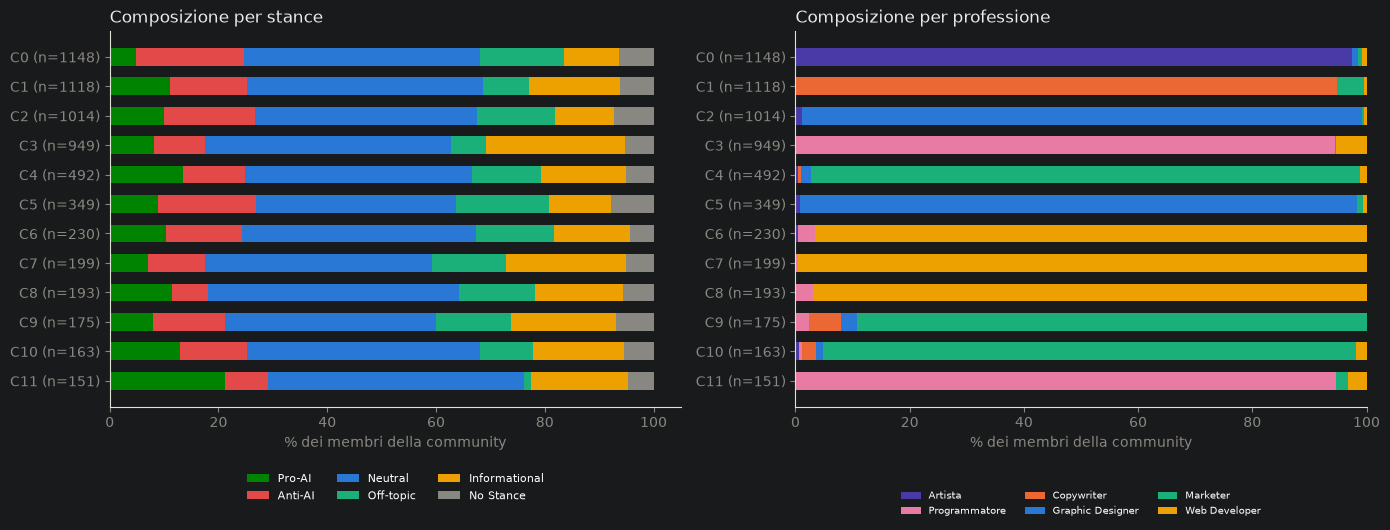

In [70]:
# Step 5.8: composizione delle community principali per stance e professione
PROFESSION_COLORS = {
    "Artista":          "#4a3aa7",
    "Programmatore":    "#e87ba4",
    "Copywriter":       "#eb6834",
    "Graphic Designer": "#2a78d6",
    "Marketer":         "#1baf7a",
    "Web Developer":    "#eda100",
}

TOP_N_COMMUNITIES = 12
top_stats = community_stats.head(TOP_N_COMMUNITIES)
top_ids = top_stats["community"].tolist()
top_members = nodes_df[nodes_df["community"].isin(top_ids)]
comm_labels = [f"C{cid} (n={size})" for cid, size in zip(top_stats["community"], top_stats["size"])]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Composizione per stance (6 etichette)
ax = axes[0]
stance_ct = pd.crosstab(top_members["community"], top_members["stance"]).reindex(columns=ALL_LABELS, fill_value=0)
stance_pct = (stance_ct.div(stance_ct.sum(axis=1), axis=0) * 100).loc[top_ids]
left = pd.Series(0.0, index=stance_pct.index)
for label in ALL_LABELS:
    ax.barh(comm_labels, stance_pct[label], left=left, color=STANCE_COLORS[label], label=label, height=0.6)
    left += stance_pct[label].values
ax.set_xlabel("% dei membri della community", color=MUTED_TEXT)
ax.set_title("Composizione per stance", color=PRIMARY_INK, loc="left")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False, fontsize=8)

# Composizione per professione
ax = axes[1]
prof_columns = list(PROFESSION_COLORS.keys())
prof_ct = pd.crosstab(top_members["community"], top_members["profession"]).reindex(columns=prof_columns, fill_value=0)
prof_pct = (prof_ct.div(prof_ct.sum(axis=1), axis=0) * 100).loc[top_ids]
left = pd.Series(0.0, index=prof_pct.index)
for label in prof_columns:
    ax.barh(comm_labels, prof_pct[label], left=left, color=PROFESSION_COLORS[label], label=label, height=0.6)
    left += prof_pct[label].values
ax.set_xlabel("% dei membri della community", color=MUTED_TEXT)
ax.set_title("Composizione per professione", color=PRIMARY_INK, loc="left")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False, fontsize=7)

for ax in axes:
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(MUTED_GRID)
    ax.tick_params(colors=MUTED_TEXT)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()


## 5.9 Nodi ponte (betweenness)

I nodi con betweenness centrality alta stanno su molti cammini minimi tra coppie di altri utenti: sono i "ponti" che collegano bolle diverse (di professione o di stance): si usa il metodo offerto da `networkx`, che si basa su un campione di `k` nodi sorgente, con lo stesso seed di riproducibilità già usato per Leiden.

,betweenness,stance,profession,community
Agile-Music-2295,0.1056,Informational,Copywriter,1
alone_in_the_light,0.0570,Neutral,Marketer,4
SaaSWriters,0.0533,Anti-AI,Copywriter,1
chervilious,0.0525,Neutral,Programmatore,11
ChickenNugsBGood,0.0477,Anti-AI,Programmatore,9
halfanothersdozen,0.0431,Neutral,Programmatore,3
moreexclamationmarks,0.0407,Neutral,Graphic Designer,5
BobbyThrowaway6969,0.0405,Neutral,Programmatore,19
Steelcitysuccubus,0.0403,Anti-AI,Artista,0
DDDDarky,0.0396,Neutral,Programmatore,11


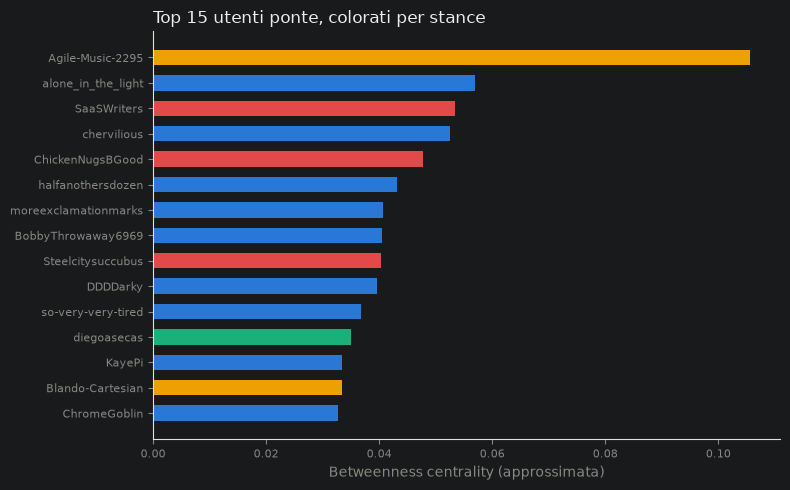


Stance dei top-15 nodi ponte: {'Neutral': 9, 'Anti-AI': 3, 'Informational': 2, 'Off-topic': 1}
Professioni distinte tra i top-15 nodi ponte: 5 su 6 totali


In [71]:
# Step 5.9: nodi ponte tramite betweenness centrality approssimata
BETWEENNESS_SAMPLE_SIZE = 500

betweenness = nx.betweenness_centrality(G, k=BETWEENNESS_SAMPLE_SIZE, seed=RANDOM_STATE)
nx.set_node_attributes(G, betweenness, "betweenness")

# Creazione df con informazioni sui ponti
top_bridges = (
    pd.Series(betweenness, name="betweenness").sort_values(ascending=False).head(15)
    .to_frame()
    .assign(
        stance=lambda d: d.index.map(user_stance),
        profession=lambda d: d.index.map(user_profession),
        community=lambda d: d.index.map(community_of),
    )
)

# Visualizzazione del DataFrame
display(top_bridges.style.format({"betweenness": "{:.4f}"}))

# Plotting dei risultati
fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = [STANCE_COLORS[s] for s in top_bridges["stance"]]
ax.barh(top_bridges.index[::-1], top_bridges["betweenness"][::-1], color=bar_colors[::-1], height=0.6)
ax.set_xlabel("Betweenness centrality (approssimata)", color=MUTED_TEXT)
ax.set_title("Top 15 utenti ponte, colorati per stance", color=PRIMARY_INK, loc="left")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color(MUTED_GRID)
ax.tick_params(colors=MUTED_TEXT, labelsize=8)
plt.tight_layout()
plt.show()

bridge_stance_counts = top_bridges["stance"].value_counts()
bridge_profession_nunique = top_bridges["profession"].nunique()
print(f"\nStance dei top-15 nodi ponte: {bridge_stance_counts.to_dict()}")
print(f"Professioni distinte tra i top-15 nodi ponte: {bridge_profession_nunique} su {len(PROFESSION_COLORS)} totali")


## 5.10 Risposta a RQ4 e RQ5
La seguente tabella riassume i risultati ottenuti dal seguente step:

| Misura                                      | Valore osservato                       | Lettura                                                                                                                |
|---------------------------------------------|----------------------------------------|------------------------------------------------------------------------------------------------------------------------|
| Assortatività per **professione**           | +0.96                                  | quasi perfetta: gli utenti si collegano quasi solo con altri della stessa professione                                  |
| Assortatività per **stance**                | +0.06                                  | vicina a zero: nessuna tendenza a collegarsi preferenzialmente con utenti dalla stessa opinione                        |
| Purezza media community per **professione** | 95%                                    | le community trovate da Leiden coincidono quasi con i confini dei subreddit di origine                                 |
| Purezza media community per **stance core** | 64% contro un baseline globale di 66% | appartenere a una community non predice l'opinione sull'AI più di quanto lo faccia già la distribuzione media generale |

Le due misure (assortatività e community detection) dimostrano quindi la medesima conclusione, si tratta del caso "assortatività bassa + community miste per stance" previsto nell'introduzione: cross-pollination diffusa sulla stance, nessuna bolla di opinione dominante.

Alla stessa maniera per le professioni si nota il caso "assortatività alta + community omogenee per professione": le discussioni avvengono tra utenti con stessa professione, tranne qualche raro caso (nodi ponte) trovato calcolando la betwenness centrality di alcuni nodi.

### RQ5 (bolle professionali):
La community detection ricalca quasi esattamente i subreddit di origine.
Ciò significa che i professionisti **non** condividono ampiamente le discussioni con professioni diverse: si trovano in bolle nette, separate per campo lavorativo.
I pochi nodi ad alta betweenness (punto 5.9) sono gli utenti che attraversano più di una bolla professionale, e sono rari.

### RQ4 (echo-chamber vs cross-pollination):
Dentro ciascuna bolla professionale, la stance verso l'AI **non** è segregata: Pro-AI, Anti-AI e Neutral si mescolano nella stessa proporzione osservata a livello globale. Non emergono quindi echo-chamber di opinione, la segregazione osservata nella rete è **per professione, non per opinione sull'AI**.